In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import nlopt
import pickle
import os
from datetime import datetime
import pandas as pd
import tempfile
import shutil
import multiprocessing as mp

import matplotlib as mpl
plt.style.use('./plotstyle.mplstyle')
import libskit

print(f"LIBSkit version: {libskit.__version__}")

# fix seed for reproducibility
np.random.seed(42)

LIBSkit version: 0.2


# 1. Spectral fitting of simulated spectra

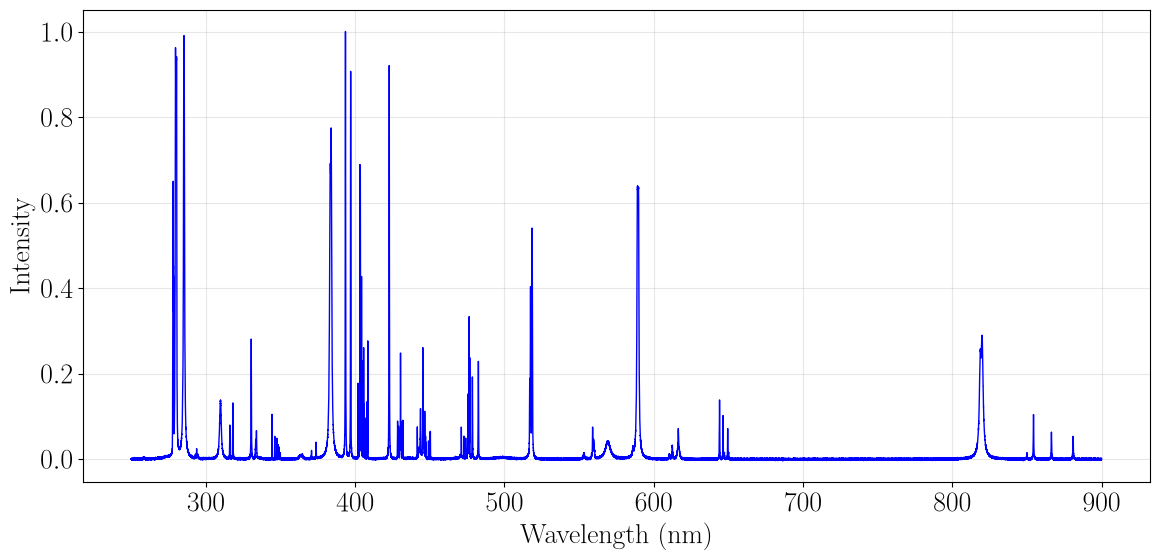

In [2]:
# Create the "true" plasma model with known parameters (what we want to recover)
true_element_ratio = {
    "Na": 0.5,
    "Mn": 0.25,
    "Mg": 0.20,
    "Ca": 0.05,
}

true_model = libskit.LTEModel(
    true_element_ratio,
    8300.0,  # temperature [K]
    2.3e23,  # electron density [m^-3]
    3e-4     # length [m]
)

# Generate synthetic "experimental" spectrum
wavelengths = np.arange(250, 900, 0.01) 
instrument = libskit.GenericSpectrometer(0.05, 0.001)
true_spectrum = instrument.calculate_spectrum(wavelengths, true_model)

# Normalize the clean spectrum to maximum intensity
true_spectrum = true_spectrum/ np.max(true_spectrum)

# Add noise relative to the normalized spectrum
noise_level = 0.001
noise = np.random.normal(0, noise_level * np.max(true_spectrum), len(true_spectrum))
true_spectrum = true_spectrum + noise 

experimental_spectrum = libskit.Spectrum(wavelengths, true_spectrum)

# Plot the target spectrum
plt.figure(figsize=(12, 6))
plt.plot(wavelengths, true_spectrum.real, 'b-', linewidth=1)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
guess_model = libskit.LTEModel(
{
    "Na": 0.5,
    "Mn": 0.25,
    "Mg": 0.20,
    "Ca": 0.05,
},

    8300.0,  # temperature [K]
    2.3e23,    # electron density [m^-3]
    3e-4     # length [m]
)


# Create experiment for optimization 
test_experiment = libskit.Experiment(
    libskit.LossType.L2Loss,
    guess_model,
    instrument, 
    experimental_spectrum, 
    libskit.NormalizationType.AnalyticNorm
)

loss_test = libskit.loss(test_experiment)
print(f"Loss of true spectrum compared to itself: {loss_test:.6f}")

Loss of true spectrum compared to itself: 0.065132


In [4]:
# Create initial guess (perturbed from true values - intentionally wrong)
guess_model = libskit.LTEModel(
    {
        "Na": 0.25,   # True: 0.5
        "Mn": 0.25,   # True: 0.25  
        "Mg": 0.25,   # True: 0.20
        "Ca": 0.25,   # True: 0.05
    },
    10000.0,   # Wrong temperature (true: 8300)
    1e23,      # Wrong density (true: 2.3e23)
    1e-4       # Wrong length (true: 3e-4)
)

# Create experiment for optimization 
experiment = libskit.Experiment(
    libskit.LossType.L2Loss,
    guess_model,
    instrument, 
    experimental_spectrum, 
    libskit.NormalizationType.AnalyticNorm
)

In [5]:
# Run optimization with NLopt L-BFGS
optimizer = libskit.Optimizer(experiment, parametrization=libskit.Parametrization.LOG_SOFTMAX_ALR)
fixed_results = optimizer.optimize(algorithm=nlopt.LD_LBFGS, max_eval=500, verbose=True, xtol_rel=1e-4)

Optimizer: Limited-memory BFGS (L-BFGS) (local, derivative-based)
Parameters (7): ['temperature', 'electron_density', 'length', 'Ca', 'Mg', 'Mn', 'Na']
Max evaluations: 500
Iter    1: Loss=2.4878e+02  temperature=10000  electron_density=1.00e+23  length=1.000e-04  Ca=0.2500  Mg=0.2500  Mn=0.2500  Na=0.2500
Iter    2: Loss=3.0175e+02  temperature=5000  electron_density=1.16e+23  length=1.069e-04  Ca=0.2450  Mg=0.2560  Mn=0.2497  Na=0.2493
Iter    3: Loss=1.0433e+02  temperature=7621  electron_density=1.06e+23  length=1.026e-04  Ca=0.2480  Mg=0.2524  Mn=0.2499  Na=0.2497
Iter   11: Loss=1.8199e+01  temperature=8263  electron_density=2.38e+23  length=1.497e-04  Ca=0.1413  Mg=0.3507  Mn=0.2735  Na=0.2345
Iter   21: Loss=1.3641e+00  temperature=8179  electron_density=2.70e+23  length=1.623e-04  Ca=0.0505  Mg=0.2501  Mn=0.2650  Na=0.4345
  Converged after 7.7s (28 evals): XTOL_REACHED — parameter tolerance xtol reached. final loss = 6.5130e-02


In [6]:
print(f"\n" + "="*80)
print(f"SUMMARY")
print(f"="*80)
print(f"Iterations: {fixed_results['n_evaluations']}")
print(f"Initial loss: {fixed_results['history']['loss'][0]:.2e}")
print(f"Final loss: {fixed_results['final_loss']:.2e}")

final_temp = fixed_results['history']['temperature'][-1]
final_density = fixed_results['history']['electron_density'][-1]
final_length = fixed_results['history']['length'][-1]

print(f"\nFinal parameter values:")
print(f"  Temperature: {final_temp:.3f} K (true: {true_model.temperature:.1f} K)")
print(f"  Electron density: {final_density:.8e} m^-3 (true: {true_model.electron_density:.2e} m^-3)")
print(f"  Length: {final_length:.8e} m (true: {true_model.length:.8e} m)")
print("  Elements:")
for element in guess_model.element_ratio.keys():
    final_val = fixed_results['history'][element][-1]
    true_val = true_element_ratio[element]
    error = abs(final_val - true_val) / true_val * 100
    print(f"    {element}: {final_val:.8f} (true: {true_val:.8f}, error: {error:.1f}%)")

# Update model with final results
guess_model.temperature = final_temp
guess_model.electron_density = final_density
guess_model.length = final_length
for element in guess_model.element_ratio.keys():
    guess_model.set_element_ratio(element, fixed_results['history'][element][-1])


SUMMARY
Iterations: 28
Initial loss: 2.49e+02
Final loss: 6.51e-02

Final parameter values:
  Temperature: 8299.727 K (true: 8300.0 K)
  Electron density: 2.30014894e+23 m^-3 (true: 2.30e+23 m^-3)
  Length: 2.99783929e-04 m (true: 3.00000000e-04 m)
  Elements:
    Ca: 0.05002636 (true: 0.05000000, error: 0.1%)
    Mg: 0.20009958 (true: 0.20000000, error: 0.0%)
    Mn: 0.25000341 (true: 0.25000000, error: 0.0%)
    Na: 0.49987065 (true: 0.50000000, error: 0.0%)


/tmp/ipykernel_17888/3551719934.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


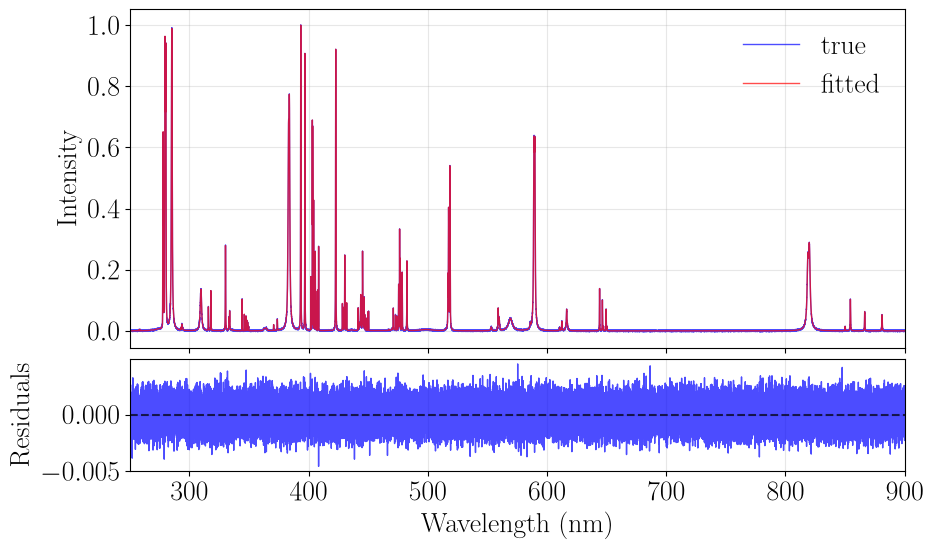

In [7]:
final_model = guess_model
element_histories = {el: fixed_results['history'][el] for el in guess_model.element_ratio.keys()}
temperatures = fixed_results['history']['temperature']
electron_densities = fixed_results['history']['electron_density']
lengths = fixed_results['history']['length']
loss_history = fixed_results['history']['loss']

# Create first visualization: Spectrum and Residuals with shared x-axis
fig_spectrum, (ax_spec, ax_res) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, 
                                                 gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

################################
# Top subplot - Spectrum Comparison #
################################
ax_spec.plot(wavelengths, true_spectrum, 'b-', linewidth=1, alpha=0.7, label='true')
final_spectrum = instrument.calculate_spectrum(wavelengths, final_model)
ax_spec.plot(wavelengths, final_spectrum/np.max(final_spectrum), 'r-', linewidth=1, alpha=0.7, label='fitted')
ax_spec.set_ylabel('Intensity')
ax_spec.legend(frameon=False)
ax_spec.grid(True, alpha=0.3)
ax_spec.set_xlim(250, 900)
ax_spec.tick_params(axis='x', labelbottom=False)

######################
# Bottom subplot - Residuals #
######################
residuals = final_spectrum/np.max(final_spectrum) - true_spectrum
ax_res.plot(wavelengths, residuals, 'b-', linewidth=1, alpha=0.7)
ax_res.axhline(y=0, color='black', linestyle='--', alpha=0.7)
ax_res.set_xlabel('Wavelength (nm)')
ax_res.set_ylabel('Residuals')
ax_res.grid(True, alpha=0.3)
ax_res.set_xlim(250, 900)

plt.tight_layout()
plt.show()

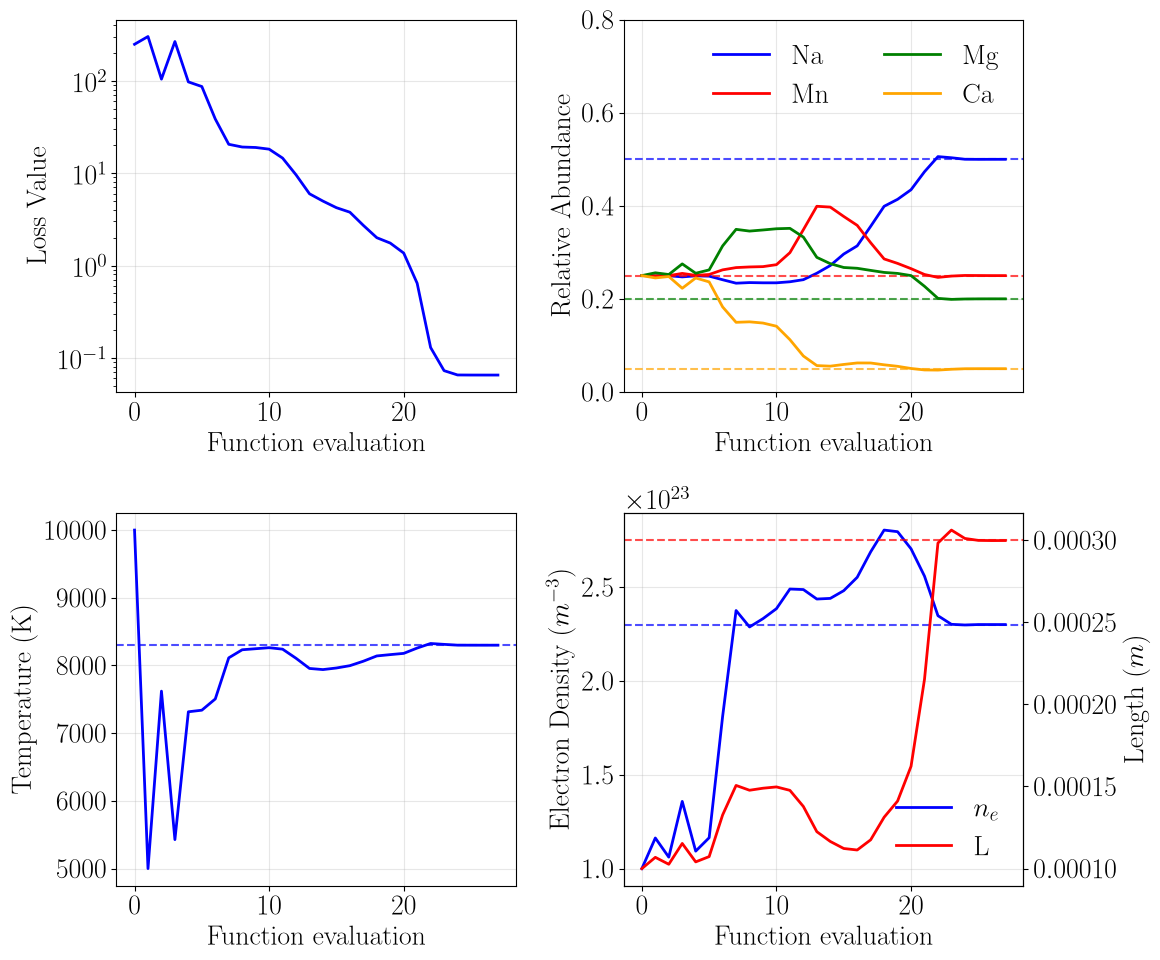

In [8]:
fig_params, axes_params = plt.subplots(2, 2, figsize=(12, 10))

##########################
# Plot 1 - Loss function #
##########################
loss_iterations = np.arange(len(fixed_results['history']['loss']))
axes_params[0, 0].semilogy(loss_iterations, loss_history, 'b-', linewidth=2)
axes_params[0, 0].set_xlabel('Function evaluation')
axes_params[0, 0].set_ylabel('Loss Value')
axes_params[0, 0].grid(True, alpha=0.3)

#########################################
# Plot 2 - Element ratios per iteration #
#########################################
param_iterations = np.arange(len(temperatures))
colors = ['blue', 'red', 'green', 'orange']
element_names = ["Na", "Mn", "Mg", "Ca"]

for i, element in enumerate(element_names):
    axes_params[0, 1].plot(param_iterations[:len(element_histories[element])], 
                   element_histories[element], 
                   color=colors[i], linewidth=2, label=f'{element}')
    axes_params[0, 1].axhline(y=true_element_ratio[element], 
                          color=colors[i], linestyle='--', alpha=0.7)
    
axes_params[0, 1].set_xlabel('Function evaluation')
axes_params[0, 1].set_ylabel('Relative Abundance')
axes_params[0, 1].set_ylim(0, 0.8)
axes_params[0, 1].legend(frameon=False, ncol=2)
axes_params[0, 1].grid(True, alpha=0.3)

######################################
# Plot 3 - Temperature per iteration #
######################################
axes_params[1, 0].plot(param_iterations, np.array(temperatures), 'b-', linewidth=2)
axes_params[1, 0].axhline(y=true_model.temperature, color='blue', linestyle='--', alpha=0.7)
axes_params[1, 0].set_xlabel('Function evaluation')
axes_params[1, 0].set_ylabel('Temperature (K)')
axes_params[1, 0].grid(True, alpha=0.3)

####################################
# Plot 4 - n_e and L per iteration #
####################################
ax_density = axes_params[1, 1]
ax_length = ax_density.twinx()

line1 = ax_density.plot(param_iterations, np.array(electron_densities), 'b-', linewidth=2, label='$n_e$')
ax_density.axhline(y=true_model.electron_density, color='blue', linestyle='--', alpha=0.7)

line2 = ax_length.plot(param_iterations, np.array(lengths), 'red', linewidth=2, label='L')
ax_length.axhline(y=true_model.length, color='red', linestyle='--', alpha=0.7)

ax_density.set_xlabel('Function evaluation')
ax_density.set_ylabel('Electron Density ($ m^{-3}$)')
ax_length.set_ylabel('Length ($ m$)')
ax_density.grid(True, alpha=0.3)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax_density.legend(lines, labels, loc='lower right', frameon=False)

plt.tight_layout()
plt.show()

In [9]:
# Save the combined spectrum+residuals figure
fig_spectrum.savefig('./figures/spectral_fit.pdf', bbox_inches='tight')
print("Saved: spectral_fit.pdf")

# Save the combined parameter evolution figure
fig_params.savefig('./figures/parameter_evolution.pdf', bbox_inches='tight')
print("Saved: parameter_evolution.pdf")

# Also save individual parameter evolution subplots
subplot_labels = ['a', 'b', 'c', 'd']

# Plot 1 - Loss function
fig_loss = plt.figure(figsize=(6, 4))
ax_loss = fig_loss.add_subplot(111)
ax_loss.semilogy(loss_iterations, loss_history, 'b-', linewidth=2)
ax_loss.set_xlabel('Function evaluation')
ax_loss.set_ylabel('Loss Value')
ax_loss.grid(True, alpha=0.3)
plt.tight_layout()
fig_loss.savefig('./figures/parameter_evolution_a.pdf', bbox_inches='tight')
plt.close(fig_loss)
print("Saved: parameter_evolution_a.pdf")

# Plot 2 - Element ratios
fig_elem = plt.figure(figsize=(6, 4))
ax_elem = fig_elem.add_subplot(111)
for i, element in enumerate(element_names):
    ax_elem.plot(param_iterations[:len(element_histories[element])], 
                 element_histories[element], 
                 color=colors[i], linewidth=2, label=f'{element}')
    ax_elem.axhline(y=true_element_ratio[element], 
                    color=colors[i], linestyle='--', alpha=0.7)
ax_elem.set_xlabel('Function evaluation')
ax_elem.set_ylabel('Relative Abundance')
ax_elem.set_ylim(0, 0.8)
ax_elem.legend(frameon=False, ncol=2)
ax_elem.grid(True, alpha=0.3)
plt.tight_layout()
fig_elem.savefig('./figures/parameter_evolution_b.pdf', bbox_inches='tight')
plt.close(fig_elem)
print("Saved: parameter_evolution_b.pdf")

# Plot 3 - Temperature
fig_temp = plt.figure(figsize=(6, 4))
ax_temp = fig_temp.add_subplot(111)
ax_temp.plot(param_iterations, np.array(temperatures), 'b-', linewidth=2)
ax_temp.axhline(y=true_model.temperature, color='blue', linestyle='--', alpha=0.7)
ax_temp.set_xlabel('Function evaluation')
ax_temp.set_ylabel('Temperature (K)')
ax_temp.grid(True, alpha=0.3)
plt.tight_layout()
fig_temp.savefig('./figures/parameter_evolution_c.pdf', bbox_inches='tight')
plt.close(fig_temp)
print("Saved: parameter_evolution_c.pdf")

# Plot 4 - Electron density and Length
fig_ne_l = plt.figure(figsize=(6, 4))
ax_ne = fig_ne_l.add_subplot(111)
ax_l = ax_ne.twinx()
line1 = ax_ne.plot(param_iterations, np.array(electron_densities), 'b-', linewidth=2, label='$n_e$')
ax_ne.axhline(y=true_model.electron_density, color='blue', linestyle='--', alpha=0.7)
line2 = ax_l.plot(param_iterations, np.array(lengths), 'red', linewidth=2, label='L')
ax_l.axhline(y=true_model.length, color='red', linestyle='--', alpha=0.7)
ax_ne.set_xlabel('Function evaluation')
ax_ne.set_ylabel('Electron Density ($ m^{-3}$)')
ax_l.set_ylabel('Length ($ m$)')
ax_ne.grid(True, alpha=0.3)
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax_ne.legend(lines, labels, loc='lower right', frameon=False)
plt.tight_layout()
fig_ne_l.savefig('./figures/parameter_evolution_d.pdf', bbox_inches='tight')
plt.close(fig_ne_l)
print("Saved: parameter_evolution_d.pdf")

Saved: spectral_fit.pdf
Saved: parameter_evolution.pdf
Saved: parameter_evolution_a.pdf
Saved: parameter_evolution_b.pdf
Saved: parameter_evolution_c.pdf
Saved: parameter_evolution_d.pdf


# 2. Convergence test: different starting points

In [10]:
def generate_initial_guesses(num_samples, bounds, element_names):
    """Generate evenly distributed initial guesses from parameter bounds.
    
    Parameters:
    -----------
    num_samples : int
        Number of initial guesses to generate
    bounds : dict
        Dictionary with 'lower' and 'upper' arrays for parameter bounds
    element_names : list
        List of element names
    
    Returns:
    --------
    list of dicts: Initial parameter sets
    """
    from scipy.stats import qmc
    
    n_params = len(bounds['lower'])
    
    # Use Latin Hypercube Sampling for better space coverage
    sampler = qmc.LatinHypercube(d=n_params, seed=42)
    samples = sampler.random(n=num_samples)
    
    # Scale samples to bounds
    lower = np.array(bounds['lower'])
    upper = np.array(bounds['upper'])
    scaled_samples = qmc.scale(samples, lower, upper)
    
    # Convert to list of parameter dictionaries
    initial_guesses = []
    for sample in scaled_samples:
        guess = {
            'temperature': sample[0],
            'electron_density': sample[1],
            'length': sample[2],
            'elements': {element_names[i]: sample[3+i] for i in range(len(element_names))}
        }
        # Normalize elements to sum to 1
        element_sum = sum(guess['elements'].values())
        guess['elements'] = {k: v/element_sum for k, v in guess['elements'].items()}
        initial_guesses.append(guess)
    
    return initial_guesses


def run_single_optimization(run_index, guess, max_eval, xtol_rel=1e-8):
    """Run a single optimization (for parallel execution)."""
    # Create model with this starting point
    test_model = libskit.LTEModel(
        guess['elements'],
        guess['temperature'],
        guess['electron_density'],
        guess['length']
    )
    
    # Create experiment
    test_experiment = libskit.Experiment(
        libskit.LossType.L2Loss,
        test_model,
        instrument,
        experimental_spectrum, 
        libskit.NormalizationType.AnalyticNorm
    )
    
    # Run optimization
    test_optimizer = libskit.Optimizer(test_experiment, parametrization=libskit.Parametrization.LOG_SOFTMAX_ALR)
    result = test_optimizer.optimize(algorithm=nlopt.LD_LBFGS, max_eval=max_eval, xtol_rel=xtol_rel)
    
    # Store results
    result['initial_guess'] = guess
    result['run_index'] = run_index
    
    print(f"Run {run_index + 1}: {'✓ Success' if result.get('status') == 'success' else '✗ Failed'} "
          f"- Final loss: {result['final_loss']:.4e}")
    
    return result


def run_convergence_test(num_samples, max_eval=500, num_processes=None, xtol_rel=1e-8):
    """Run optimization from multiple starting points in parallel.
    
    Parameters:
    -----------
    num_samples : int
        Number of different starting points to test
    max_eval : int
        Maximum evaluations per optimization run
    num_processes : int or None
        Number of parallel processes (defaults to CPU count)
        
    Returns:
    --------
    list: Results from all runs
    """
    import multiprocessing as mp
    from functools import partial
    
    temp_optimizer = libskit.Optimizer(
        experiment,
        parametrization=libskit.Parametrization.LOG_SOFTMAX_ALR,
    )
    element_names = list(true_element_ratio.keys())
    param_order = ['temperature', 'electron_density', 'length'] + element_names
    name_to_idx = {n: i for i, n in enumerate(temp_optimizer.param_names)}
    bounds = {
        'lower': np.array([temp_optimizer._lower[name_to_idx[n]] for n in param_order]),
        'upper': np.array([temp_optimizer._upper[name_to_idx[n]] for n in param_order])
    }
    
    # Generate initial guesses
    initial_guesses = generate_initial_guesses(num_samples, bounds, element_names)
    
    # Set up parallel processing
    if num_processes is None:
        num_processes = min(mp.cpu_count(), num_samples)
    
    print(f"\nRunning {num_samples} optimizations in parallel using {num_processes} processes...")
    print("=" * 80)
    
    # Create partial function with fixed max_eval
    run_partial = partial(run_single_optimization, max_eval=max_eval, xtol_rel=xtol_rel)
    
    # Run parallel processing
    import time
    start_time = time.time()
    
    with mp.Pool(processes=num_processes) as pool:
        results = pool.starmap(run_partial, enumerate(initial_guesses))
    
    end_time = time.time()
    
    print(f"\n" + "=" * 80)
    print(f"PARALLEL EXECUTION COMPLETED")
    print(f"=" * 80)
    print(f"Total execution time: {end_time - start_time:.2f} seconds")
    print(f"Average time per run: {(end_time - start_time) / num_samples:.2f} seconds")
    
    return results

In [11]:
import pickle
from pathlib import Path

# save results to pickle file so we don't have to rerun the convergence test every time
convergence_file = Path('convergence_results.pkl')
if convergence_file.exists():
    with open(convergence_file, 'rb') as f:
        convergence_results = pickle.load(f)
    print(f"Loaded convergence results from {convergence_file}")
else:
    convergence_results = run_convergence_test(
        num_samples=8, max_eval=500, num_processes=8 # in paper: 256 starts, here: 8 for testing
    )
    with open(convergence_file, 'wb') as f:
        pickle.dump(convergence_results, f)
    print(f"Saved convergence results to {convergence_file}")

Loaded convergence results from convergence_results.pkl


In [12]:
unsuccessful_runs = [res for res in convergence_results if res.get('status') != 'success']
print(f"\nUnsuccessful runs: {len(unsuccessful_runs)} / {len(convergence_results)}")

for unsuccessful_run in unsuccessful_runs:

    # print index, final loss and and fail reason
    run_index = unsuccessful_run['run_index']
    final_loss = unsuccessful_run['final_loss']
    reason = unsuccessful_run['reason']

    print(f"Run {run_index + 1}: Final loss = {final_loss:.4e}, Reason = {reason}")
    print("-" * 40)


Unsuccessful runs: 0 / 8


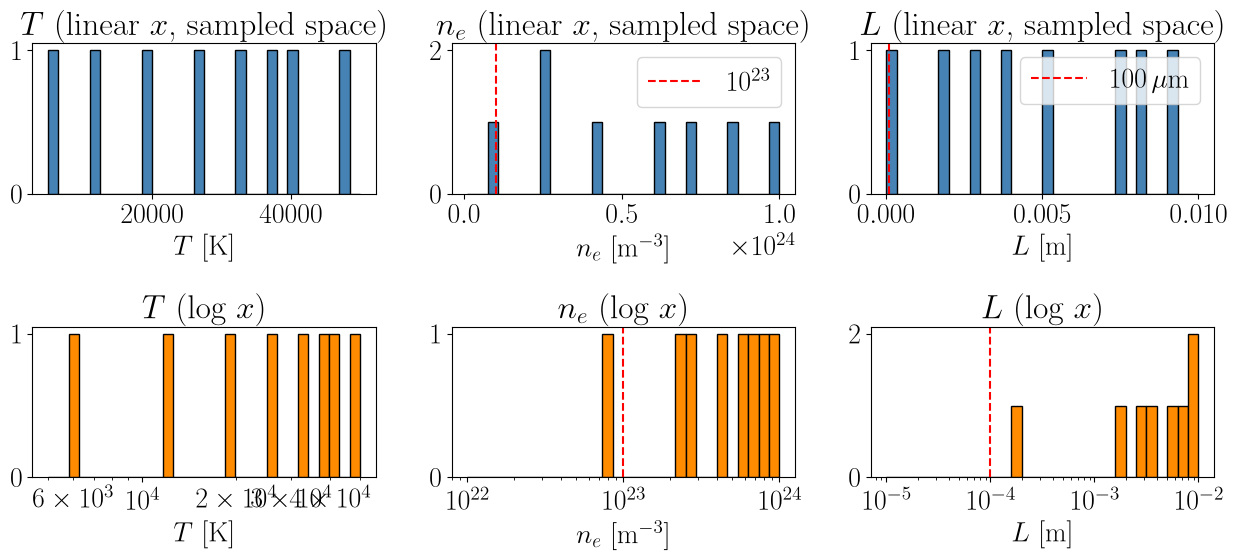

Total starts: 8

n_e decade counts:
  [1e+22, 1e+23) :    1  ( 12.5%)
  [1e+23, 1e+24) :    7  ( 87.5%)

L decade counts:
  [1e-05, 1e-04) :    0  (  0.0%)
  [1e-04, 1e-03) :    1  ( 12.5%)
  [1e-03, 1e-02) :    7  ( 87.5%)

min(n_e) = 7.944e+22
min(L)   = 1.866e-04


In [13]:
import matplotlib.pyplot as plt

ne_arr = np.array([r['initial_guess']['electron_density'] for r in convergence_results])
T_arr  = np.array([r['initial_guess']['temperature']      for r in convergence_results])
L_arr  = np.array([r['initial_guess']['length']           for r in convergence_results])

ne_lo, ne_hi = 1e22, 1e24
T_lo,  T_hi  = 5_000, 50_000
L_lo,  L_hi  = 1e-5, 1e-2

fig, axes = plt.subplots(2, 3, figsize=(13, 6))

# Top row: linear x-axis (the space LHS actually samples in)
axes[0, 0].hist(T_arr, bins=30, range=(T_lo, T_hi), color='steelblue', edgecolor='k')
axes[0, 0].set_title(r'$T$ (linear $x$, sampled space)'); axes[0, 0].set_xlabel(r'$T$ [K]')
axes[0, 1].hist(ne_arr, bins=30, range=(ne_lo, ne_hi), color='steelblue', edgecolor='k')
axes[0, 1].set_title(r'$n_e$ (linear $x$, sampled space)'); axes[0, 1].set_xlabel(r'$n_e$ [m$^{-3}$]')
axes[0, 1].axvline(1e23, color='r', ls='--', label=r'$10^{23}$')
axes[0, 1].legend()
axes[0, 2].hist(L_arr, bins=30, range=(L_lo, L_hi), color='steelblue', edgecolor='k')
axes[0, 2].set_title(r'$L$ (linear $x$, sampled space)'); axes[0, 2].set_xlabel(r'$L$ [m]')
axes[0, 2].axvline(1e-4, color='r', ls='--', label=r'$100\,\mu$m'); axes[0, 2].legend()

# Bottom row: log x-axis (how a physicist usually thinks about these)
log_bins_T  = np.logspace(np.log10(T_lo),  np.log10(T_hi),  31)
log_bins_ne = np.logspace(np.log10(ne_lo), np.log10(ne_hi), 31)
log_bins_L  = np.logspace(np.log10(L_lo),  np.log10(L_hi),  31)

axes[1, 0].hist(T_arr, bins=log_bins_T, color='darkorange', edgecolor='k')
axes[1, 0].set_xscale('log'); axes[1, 0].set_title(r'$T$ (log $x$)'); axes[1, 0].set_xlabel(r'$T$ [K]')
axes[1, 1].hist(ne_arr, bins=log_bins_ne, color='darkorange', edgecolor='k')
axes[1, 1].set_xscale('log'); axes[1, 1].set_title(r'$n_e$ (log $x$)'); axes[1, 1].set_xlabel(r'$n_e$ [m$^{-3}$]')
axes[1, 1].axvline(1e23, color='r', ls='--')
axes[1, 2].hist(L_arr, bins=log_bins_L, color='darkorange', edgecolor='k')
axes[1, 2].set_xscale('log'); axes[1, 2].set_title(r'$L$ (log $x$)'); axes[1, 2].set_xlabel(r'$L$ [m]')
axes[1, 2].axvline(1e-4, color='r', ls='--')

plt.tight_layout()
plt.show()

print(f'Total starts: {len(ne_arr)}')
print()
print('n_e decade counts:')
for lo, hi in [(1e22, 1e23), (1e23, 1e24)]:
    n = ((ne_arr >= lo) & (ne_arr < hi)).sum()
    print(f'  [{lo:.0e}, {hi:.0e}) : {n:4d}  ({100*n/len(ne_arr):5.1f}%)')
print()
print('L decade counts:')
for lo, hi in [(1e-5, 1e-4), (1e-4, 1e-3), (1e-3, 1e-2)]:
    n = ((L_arr >= lo) & (L_arr < hi)).sum()
    print(f'  [{lo:.0e}, {hi:.0e}) : {n:4d}  ({100*n/len(L_arr):5.1f}%)')
print()
print(f'min(n_e) = {ne_arr.min():.3e}')
print(f'min(L)   = {L_arr.min():.3e}')

n_evaluations:  median=48  IQR=[40, 56]  min=37  max=83
final_loss:     min=6.5127e-02  max=6.5128e-02  spread=1.57e-06


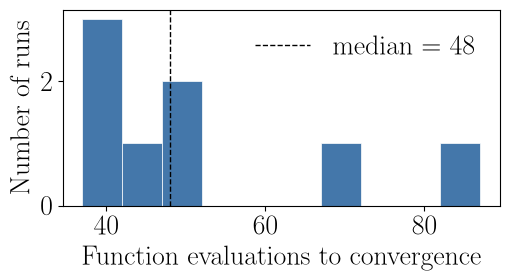

In [14]:
n_evals = np.asarray([r['n_evaluations'] for r in convergence_results])
losses  = np.asarray([r['final_loss']    for r in convergence_results])

med = int(np.median(n_evals))
q25, q75 = np.percentile(n_evals, [25, 75])
print(f"n_evaluations:  median={med}  IQR=[{int(q25)}, {int(q75)}]  "
      f"min={int(n_evals.min())}  max={int(n_evals.max())}")
print(f"final_loss:     min={losses.min():.4e}  max={losses.max():.4e}  "
      f"spread={losses.max()-losses.min():.2e}")

fig_iters, ax_iters = plt.subplots(figsize=(5.5, 3.2))
bins = np.arange(n_evals.min(), n_evals.max() + 5, 5)
ax_iters.hist(n_evals, bins=bins, color="#4477AA",
              edgecolor="white", linewidth=0.5)
ax_iters.axvline(med, color="black", linestyle="--", linewidth=1.0,
                 label=f"median = {med}")
ax_iters.set_xlabel("Function evaluations to convergence")
ax_iters.set_ylabel("Number of runs")
ax_iters.legend(frameon=False, loc="upper right")
fig_iters.tight_layout()
fig_iters.savefig("./figures/convergence_iterations.pdf", bbox_inches="tight")
plt.show()


# 3. Comparison of Normalizations


In [15]:
print("\n" + "="*70)
print("SECTION 3: NORMALIZATION STRATEGY COMPARISON")
print("="*70)

normalization_results = {}

for norm_type in [libskit.NormalizationType.AnalyticNorm, libskit.NormalizationType.MaxNorm, libskit.NormalizationType.OptimizedScaleNorm]:
    norm_name = "Analytic" if norm_type == libskit.NormalizationType.AnalyticNorm else "Max" if norm_type == libskit.NormalizationType.MaxNorm else "Optimized"
    print(f"\n--- {norm_name} ---")
    
    # Fresh initial guess for fair comparison
    guess_model = libskit.LTEModel(
        {"Na": 0.25, "Mn": 0.25, "Mg": 0.25, "Ca": 0.25},
        10000.0,   # Wrong: true is 8300 K
        1e23,      # Wrong: true is 2.3e23 m^-3
        1e-4       # Wrong: true is 3e-4 m
    )
    
    experiment = libskit.Experiment(
        libskit.LossType.L2Loss,
        guess_model,
        instrument,
        experimental_spectrum,
        norm_type
    )
    
    import time
    start_time = time.time()
    optimizer = libskit.Optimizer(experiment, parametrization=libskit.Parametrization.LOG_SOFTMAX_ALR)
    result = optimizer.optimize(algorithm=nlopt.LD_LBFGS, max_eval=200, verbose=False, xtol_rel=1e-4)
    elapsed = time.time() - start_time
    
    normalization_results[norm_name] = result
    normalization_results[norm_name]["scale_factor"] = experiment.scale_factor
    
    print(f"  Iterations: {result['n_evaluations']}")
    print(f"  Final loss: {result['final_loss']:.4e}")
    print(f"  Scale factor: {experiment.scale_factor:.4e}")
    print(f"  Time: {elapsed:.2f}s")


print("\n✓ Normalization comparison complete!")


SECTION 3: NORMALIZATION STRATEGY COMPARISON

--- Analytic ---
  Iterations: 28
  Final loss: 6.5130e-02
  Scale factor: 1.0000e+00
  Time: 7.69s

--- Max ---
  Iterations: 34
  Final loss: 6.5306e-02
  Scale factor: 1.0000e+00
  Time: 8.54s

--- Optimized ---
  Iterations: 43
  Final loss: 6.5128e-02
  Scale factor: 1.4653e+14
  Time: 10.31s

✓ Normalization comparison complete!


In [16]:
# Compact summary of normalization + loss function results
print("=== NORMALIZATION COMPARISON (L2 loss) ===")
for norm_name, res in normalization_results.items():
    h = res["history"]
    T_err = abs(h["temperature"][-1] - 8300) / 8300 * 100
    ne_err = abs(h["electron_density"][-1] - 2.3e23) / 2.3e23 * 100
    L_err = abs(h["length"][-1] - 3e-4) / 3e-4 * 100
    true_el = {"Na": 0.5, "Mn": 0.25, "Mg": 0.20, "Ca": 0.05}
    el_errs = {}
    for el in true_el:
        rec = h[el][-1]
        total = sum(h[e][-1] for e in true_el)
        frac = rec / total
        true_frac = true_el[el]
        el_errs[el] = abs(frac - true_frac) / true_frac * 100
    sf = res.get("scale_factor", float('nan'))
    print(f"  {norm_name:25s}: iters={res['n_evaluations']:3d}  scale={sf:.4e}  T_err={T_err:.3f}%  ne_err={ne_err:.3f}%  L_err={L_err:.3f}%  "
          + "  ".join(f"{el}={el_errs[el]:.3f}%" for el in true_el))


=== NORMALIZATION COMPARISON (L2 loss) ===
  Analytic                 : iters= 28  scale=1.0000e+00  T_err=0.003%  ne_err=0.006%  L_err=0.072%  Na=0.026%  Mn=0.001%  Mg=0.050%  Ca=0.053%
  Max                      : iters= 34  scale=1.0000e+00  T_err=0.008%  ne_err=0.016%  L_err=0.256%  Na=0.044%  Mn=0.018%  Mg=0.081%  Ca=0.203%
  Optimized                : iters= 43  scale=1.4653e+14  T_err=0.003%  ne_err=0.004%  L_err=0.058%  Na=0.023%  Mn=0.006%  Mg=0.049%  Ca=0.056%


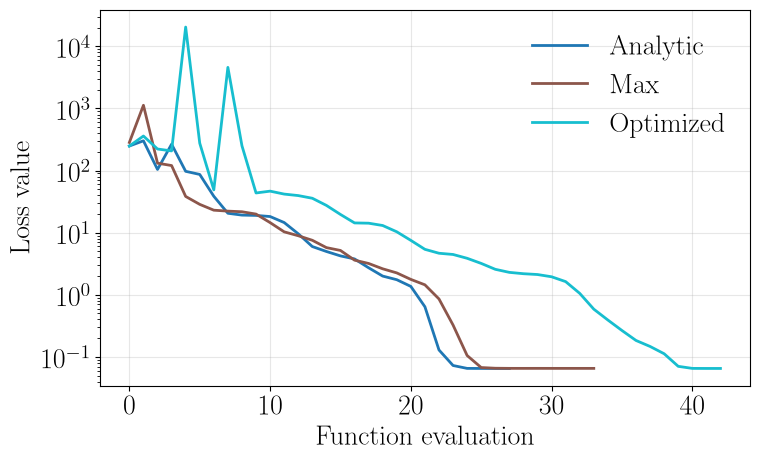

In [17]:
# ── Visualization: Normalization Comparison ───────────────────────────
norm_names = list(normalization_results.keys())
norm_colors = plt.cm.tab10(np.linspace(0, 1, max(len(norm_names), 2)))

fig_norm, ax_norm = plt.subplots(figsize=(8, 5))

for i, name in enumerate(norm_names):
    loss_hist = normalization_results[name]["history"]["loss"]
    iters = np.arange(len(loss_hist))
    ax_norm.semilogy(iters, loss_hist, color=norm_colors[i], linewidth=2, label=name)

ax_norm.set_xlabel("Function evaluation")
ax_norm.set_ylabel("Loss value")
ax_norm.legend(frameon=False)
ax_norm.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
fig_norm.savefig('./figures/normalization_comparison.pdf', bbox_inches='tight')

# 4. Comparison of Loss Functions

In [19]:
print("\n" + "=" * 70)
print("SECTION 4: LOSS FUNCTION COMPARISON")
print("=" * 70)

# ── Configuration ────────────────────────────────────────────────────
loss_types = {name: member for name, member in libskit.LossType.__members__.items()}
print(f"Available loss functions: {list(loss_types.keys())}")

# True parameters
loss_true_elements = {"Na": 0.5, "Mn": 0.25, "Mg": 0.20, "Ca": 0.05}
loss_true_T = 8300.0
loss_true_ne = 2.3e23
loss_true_L = 3e-4

# Initial guess (same as Section 1)
loss_guess_T = 10000.0
loss_guess_ne = 1e23
loss_guess_L = 1e-4
loss_guess_elements = {"Na": 0.25, "Mn": 0.25, "Mg": 0.25, "Ca": 0.25}

# Cache
loss_cache = Path("../results/loss_comparison_results.pkl")
os.makedirs("../results", exist_ok=True)
force_rerun_loss = True

# ── Run optimization for each loss function ──────────────────────────
if loss_cache.exists() and not force_rerun_loss:
    with open(loss_cache, "rb") as f:
        loss_fn_data = pickle.load(f)
    print(f"Loaded loss comparison results from cache ({len(loss_fn_data)} entries)")
else:
    loss_fn_data = {}

    for loss_name, loss_type in loss_types.items():
        print(f"\n{'=' * 60}")
        print(f"Loss function: {loss_name}")
        print(f"{'=' * 60}")

        guess_model_lf = libskit.LTEModel(
            dict(loss_guess_elements), loss_guess_T, loss_guess_ne, loss_guess_L,
        )

        experiment_lf = libskit.Experiment(
            loss_type,
            guess_model_lf,
            instrument,
            experimental_spectrum,
            libskit.NormalizationType.OptimizedScaleNorm,
        )

        t0 = time.perf_counter()
        optimizer_lf = libskit.Optimizer(experiment_lf, parametrization=libskit.Parametrization.LOG_SOFTMAX_ALR)
        result_lf = optimizer_lf.optimize(
            algorithm=nlopt.LD_LBFGS, max_eval=500, verbose=False, xtol_rel=1e-4
        )
        elapsed = time.perf_counter() - t0

        h = result_lf["history"]
        entry = {
            "loss_name": loss_name,
            "n_evaluations": result_lf["n_evaluations"],
            "final_loss": result_lf["final_loss"],
            "wall_time": elapsed,
            "loss_history": h["loss"],
            "temperature_history": h["temperature"],
            "ne_history": h["electron_density"],
            "length_history": h["length"],
            "recovered_T": h["temperature"][-1],
            "recovered_ne": h["electron_density"][-1],
            "recovered_L": h["length"][-1],
        }
        for el in loss_true_elements:
            entry[f"history_{el}"] = h[el]
            entry[f"recovered_{el}"] = h[el][-1]

        loss_fn_data[loss_name] = entry
        print(f"  loss={entry['final_loss']:.4e}  "
              f"iters={entry['n_evaluations']:3d}  "
              f"T={entry['recovered_T']:.1f} K  time={elapsed:.3f} s")

    with open(loss_cache, "wb") as f:
        pickle.dump(loss_fn_data, f)
    print(f"\nSaved to {loss_cache}")

# ── Summary table ────────────────────────────────────────────────────
print(f"\n{'Loss':>20} {'iters':>6} {'time(s)':>8} {'final_loss':>12} "
      f"{'T(K)':>8} {'ne':>10} {'L':>10}")
print("-" * 85)
for name, d in loss_fn_data.items():
    print(f"{name:>20} {d['n_evaluations']:>6} {d['wall_time']:>8.3f} "
          f"{d['final_loss']:>12.4e} {d['recovered_T']:>8.1f} "
          f"{d['recovered_ne']:>10.2e} {d['recovered_L']:>10.2e}")

print(f"\n✓ Loss function comparison complete!")


SECTION 4: LOSS FUNCTION COMPARISON
Available loss functions: ['L2Loss', 'IntensityWeightedLoss', 'L1Loss', 'LogL2Loss', 'WeightedL2Loss']

Loss function: L2Loss
  loss=6.5128e-02  iters= 43  T=8299.8 K  time=10.367 s

Loss function: IntensityWeightedLoss
  loss=3.4817e+02  iters= 67  T=8189.1 K  time=21.529 s

Loss function: L1Loss
  loss=1.7116e+02  iters= 40  T=8238.4 K  time=9.666 s

Loss function: LogL2Loss
  loss=6.3553e-02  iters= 33  T=8299.8 K  time=8.549 s

Loss function: WeightedL2Loss
  loss=6.5128e-02  iters= 43  T=8299.8 K  time=10.317 s

Saved to ../results/loss_comparison_results.pkl

                Loss  iters  time(s)   final_loss     T(K)         ne          L
-------------------------------------------------------------------------------------
              L2Loss     43   10.367   6.5128e-02   8299.8   2.30e+23   3.00e-04
IntensityWeightedLoss     67   21.529   3.4817e+02   8189.1   1.92e+23   1.32e-04
              L1Loss     40    9.666   1.7116e+02   8238.4   

In [20]:
# print the final recovered parameters for each loss function
print("\nRecovered parameters for each loss function:")
for name, d in loss_fn_data.items():
    print(f"\n{name}:")
    print(f"  Temperature: {d['recovered_T']:.2f} K (true: {loss_true_T:.2f} K)")
    print(f"  Electron density: {d['recovered_ne']:.4e} m^-3 (true: {loss_true_ne:.4e} m^-3)")
    print(f"  Length: {d['recovered_L']:.4e} m (true: {loss_true_L:.4e} m)")
    for el in loss_true_elements:
        recovered_frac = d[f"recovered_{el}"]
        true_frac = loss_true_elements[el]
        error = abs(recovered_frac - true_frac) / true_frac * 100
        print(f"  {el}: {recovered_frac:.4f} (true: {true_frac:.4f}, error: {error:.2f}%)")


Recovered parameters for each loss function:

L2Loss:
  Temperature: 8299.75 K (true: 8300.00 K)
  Electron density: 2.3001e+23 m^-3 (true: 2.3000e+23 m^-3)
  Length: 2.9982e-04 m (true: 3.0000e-04 m)
  Na: 0.4999 (true: 0.5000, error: 0.02%)
  Mn: 0.2500 (true: 0.2500, error: 0.01%)
  Mg: 0.2001 (true: 0.2000, error: 0.05%)
  Ca: 0.0500 (true: 0.0500, error: 0.06%)

IntensityWeightedLoss:
  Temperature: 8189.07 K (true: 8300.00 K)
  Electron density: 1.9189e+23 m^-3 (true: 2.3000e+23 m^-3)
  Length: 1.3179e-04 m (true: 3.0000e-04 m)
  Na: 0.2463 (true: 0.5000, error: 50.73%)
  Mn: 0.2563 (true: 0.2500, error: 2.54%)
  Mg: 0.2821 (true: 0.2000, error: 41.07%)
  Ca: 0.2152 (true: 0.0500, error: 330.35%)

L1Loss:
  Temperature: 8238.41 K (true: 8300.00 K)
  Electron density: 2.3528e+23 m^-3 (true: 2.3000e+23 m^-3)
  Length: 1.3478e-04 m (true: 3.0000e-04 m)
  Na: 0.2480 (true: 0.5000, error: 50.41%)
  Mn: 0.3775 (true: 0.2500, error: 51.00%)
  Mg: 0.2999 (true: 0.2000, error: 49.93%)
  

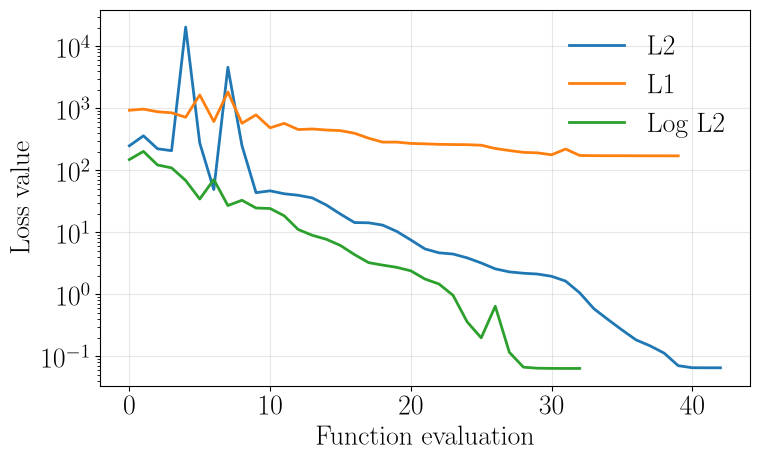

In [21]:
# ── Visualization: Loss Function Comparison ──────────────────────────
loss_names = list(loss_fn_data.keys())
loss_names_clean = {
    "L2Loss": "L2",
#    "PederLoss": "Weighted L2 ",
    "L1Loss": "L1",
    "LogL2Loss": "Log L2",
}

# Function-evaluation multiplier for L-BFGS with 7 parameters
fp_per_eval = 1  # Enzyme: 1 reverse pass per iteration

fig_lf, ax_lf = plt.subplots(figsize=(8, 5))

for i, name in enumerate(loss_names_clean.keys()):
    d = loss_fn_data[name]
    iters = np.arange(len(d["loss_history"])) * fp_per_eval
    ax_lf.semilogy(iters, d["loss_history"], linewidth=2, label=loss_names_clean[name])

ax_lf.set_xlabel("Function evaluation")
ax_lf.set_ylabel("Loss value")
ax_lf.legend(frameon=False)
ax_lf.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
fig_lf.savefig("./figures/loss_comparison.pdf", bbox_inches="tight")
print("Saved: loss_comparison.pdf")

Saved: loss_comparison.pdf


# 5. Algorithm comparison

In [23]:
# ── Configuration ────────────────────────────────────────────────────
results_dir = "./results"
os.makedirs(results_dir, exist_ok=True)

force_rerun_all = True          # wipe every cache and recompute
force_rerun     = set()          # e.g. {"L-BFGS", "CRS"} to selectively refresh

# Algorithm registry: name → (nlopt constant, max_eval)
# scaled down max_eval for testing
ALGORITHMS = {
    "L-BFGS":      (nlopt.LD_LBFGS,      500),
    "Nelder-Mead": (nlopt.LN_NELDERMEAD, 2000),
    "DIRECT":      (nlopt.GN_DIRECT,   5000),
    "DIRECT-L":    (nlopt.GN_DIRECT_L,  5000),
    "CRS":         (nlopt.GN_CRS2_LM,   5000),
    "MLSL":        (nlopt.GN_MLSL,      5000),
    "StoGO":       (nlopt.GD_STOGO,     5000),
}

# ── Helper: cache path for one algorithm ─────────────────────────────
def _cache_path(name: str) -> str:
    slug = name.lower().replace("-", "_").replace(" ", "_")
    return os.path.join(results_dir, f"algo_{slug}.pkl")

# ── Run / load each algorithm independently ──────────────────────────
algo_results = {}  # name → full results dict (includes 'history')

for i, (name, (algo_const, max_eval)) in enumerate(ALGORITHMS.items(), 1):
    cache = _cache_path(name)
    need_run = force_rerun_all or (name in force_rerun) or not os.path.exists(cache)

    if not need_run:
        with open(cache, "rb") as f:
            algo_results[name] = pickle.load(f)
        ts = algo_results[name].get("timestamp", "?")
        n  = algo_results[name]["n_evaluations"]
        fl = algo_results[name]["final_loss"]
        print(f"[{i}/{len(ALGORITHMS)}] {name:15} — loaded from cache  "
              f"({n} evals, loss={fl:.4e}, cached {ts})")
        continue

    # Fresh optimisation
    print(f"[{i}/{len(ALGORITHMS)}] {name:15} — running (max_eval={max_eval})…")
    model_i = libskit.LTEModel(
        {"Na": 0.25, "Mn": 0.25, "Mg": 0.25, "Ca": 0.25},
        10000.0, 1e23, 1e-4,
    )
    exp_i = libskit.Experiment(
        libskit.LossType.L2Loss, model_i, instrument,
        experimental_spectrum, libskit.NormalizationType.AnalyticNorm,
    )
    opt_i = libskit.Optimizer(exp_i, parametrization=libskit.Parametrization.LOG_SOFTMAX_ALR)
    res   = opt_i.optimize(algorithm=algo_const, max_eval=max_eval, verbose=False)
    res["timestamp"] = datetime.now().isoformat()

    with open(cache, "wb") as f:
        pickle.dump(res, f)

    algo_results[name] = res
    print(f"{'':19} ✓ {res['n_evaluations']} evals, "
          f"loss={res['final_loss']:.4e}  → saved to {cache}")

print(f"\nAll {len(ALGORITHMS)} algorithms ready.")

[1/7] L-BFGS          — running (max_eval=500)…
                    ✓ 28 evals, loss=6.5130e-02  → saved to ./results/algo_l_bfgs.pkl
[2/7] Nelder-Mead     — running (max_eval=2000)…
                    ✓ 367 evals, loss=6.5142e-02  → saved to ./results/algo_nelder_mead.pkl
[3/7] DIRECT          — running (max_eval=5000)…
                    ✓ 5000 evals, loss=1.8846e-01  → saved to ./results/algo_direct.pkl
[4/7] DIRECT-L        — running (max_eval=5000)…
                    ✓ 5000 evals, loss=1.4999e+00  → saved to ./results/algo_direct_l.pkl
[5/7] CRS             — running (max_eval=5000)…
                    ✓ 2514 evals, loss=3.4400e+01  → saved to ./results/algo_crs.pkl
[6/7] MLSL            — running (max_eval=5000)…
                    ✓ 5000 evals, loss=4.1438e+00  → saved to ./results/algo_mlsl.pkl
[7/7] StoGO           — running (max_eval=5000)…
                    ✓ 5000 evals, loss=1.1510e+00  → saved to ./results/algo_stogo.pkl

All 7 algorithms ready.


In [24]:
# ── Summary table ─────────────────────────────────────────────────────
print(f"{'Algorithm':15} {'Evals':>8} {'Final Loss':>14} {'Best Loss':>14}")
print("─" * 55)
for name, res in algo_results.items():
    h = res["history"]
    best = min(h["loss"])
    print(f"{name:15} {res['n_evaluations']:>8} {res['final_loss']:>14.4e} {best:>14.4e}")

Algorithm          Evals     Final Loss      Best Loss
───────────────────────────────────────────────────────
L-BFGS                28     6.5130e-02     6.5130e-02
Nelder-Mead          367     6.5142e-02     6.5142e-02
DIRECT              5000     1.8846e-01     1.8846e-01
DIRECT-L            5000     1.4999e+00     1.4999e+00
CRS                 2514     3.4400e+01     3.4400e+01
MLSL                5000     4.1438e+00     4.1438e+00
StoGO               5000     1.1510e+00     1.1510e+00


In [25]:
# ── Best parameters per algorithm ──────────────────────────────────────
# Extract the parameter values at the lowest-loss iteration for each algorithm
# and compare against the known true values.

true_values = {
    "Na": 0.5, "Mn": 0.25, "Mg": 0.20, "Ca": 0.05,
    "temperature": 8300.0, "electron_density": 2.3e23, "length": 3e-4,
}

param_names = [k for k in list(algo_results.values())[0]["history"].keys()
               if k not in ("loss", "iteration")]

# Header
header = f"{'Algorithm':15}"
for p in param_names:
    width = max(len(p), 10)
    header += f" {p:>{width}}"
print(header)
print("─" * len(header))

# True values row
row = f"{'TRUE':15}"
for p in param_names:
    width = max(len(p), 10)
    val = true_values.get(p, float("nan"))
    if val > 1e4:
        row += f" {val:>{width}.3e}"
    else:
        row += f" {val:>{width}.4f}"
print(row)
print("─" * len(header))

# Each algorithm: pick parameters at the iteration with minimum loss
for name, res in algo_results.items():
    h = res["history"]
    best_idx = int(np.argmin(h["loss"]))
    row = f"{name:15}"
    for p in param_names:
        width = max(len(p), 10)
        val = h[p][best_idx]
        if val > 1e4:
            row += f" {val:>{width}.3e}"
        else:
            row += f" {val:>{width}.4f}"
    print(row)


Algorithm       temperature electron_density     length         Ca         Mg         Mn         Na
───────────────────────────────────────────────────────────────────────────────────────────────────
TRUE              8300.0000        2.300e+23     0.0003     0.0500     0.2000     0.2500     0.5000
───────────────────────────────────────────────────────────────────────────────────────────────────
L-BFGS            8299.7273        2.300e+23     0.0003     0.0500     0.2001     0.2500     0.4999
Nelder-Mead       8299.2865        2.301e+23     0.0003     0.0500     0.2002     0.2499     0.4999
DIRECT            8305.3973        2.154e+23     0.0004     0.0489     0.1923     0.2431     0.5156
DIRECT-L          8030.2917        2.154e+23     0.0002     0.0472     0.2354     0.2823     0.4352
CRS               8841.3657        2.320e+23     0.0005     0.0520     0.2106     0.0000     0.7374
MLSL              8511.3548        1.722e+23     0.0010     0.0375     0.1391     0.1849     0.6386


/tmp/ipykernel_17888/2178365878.py:39: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 10**5)


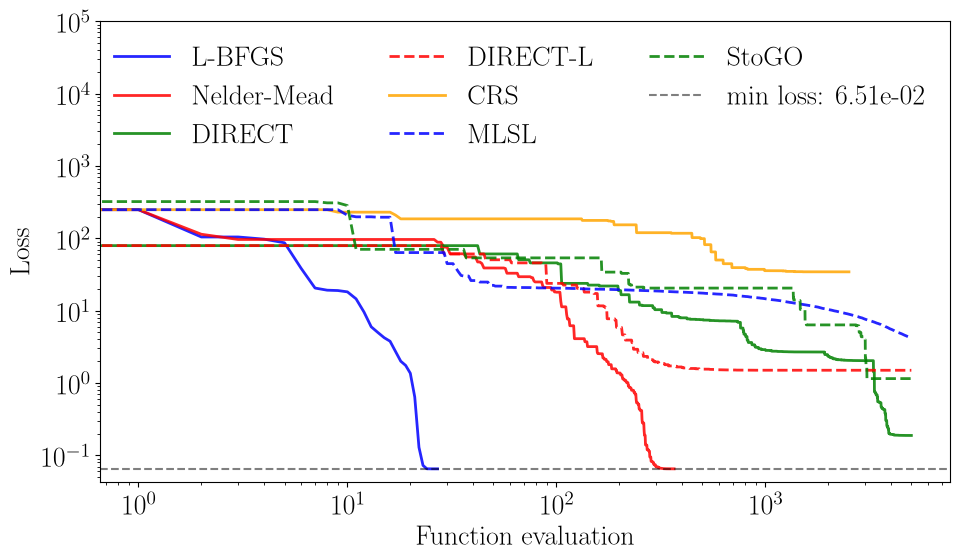

In [26]:
# ── Loss convergence: all algorithms ──────────────────────────────────
window = 1000000

def rolling_min(losses, w=window):
    """Running best-so-far (rolling minimum)."""
    arr = np.array(losses)
    return np.array([np.min(arr[max(0, i - w + 1):i + 1]) for i in range(len(arr))])

fig, ax = plt.subplots(figsize=(10, 6))

# Gradient-based algorithms: plot raw loss (smooth already)
# Global algorithms: plot rolling minimum (stochastic jumps)
gradient_algos = {"L-BFGS", "Nelder-Mead", "StoGO"}
colors = {
    "L-BFGS": "blue",    "Nelder-Mead": "red",
    "DIRECT": "green",    "DIRECT-L": "red",
    "CRS": "orange",         "MLSL": "blue",
    "StoGO": "green",
}
styles = {
    "L-BFGS": "-",  "Nelder-Mead": "-",  "StoGO": "--",
    "DIRECT": "-",  "DIRECT-L": "--",    "CRS": "-",  "MLSL": "--",
}

for name, res in algo_results.items():
    losses = res["history"]["loss"]
    y = rolling_min(losses)
    x = np.arange(len(y))
    ax.semilogy(x, y, linestyle=styles.get(name, "-"), color=colors.get(name),
                linewidth=2, label=name, alpha=0.85)

# Reference: best L-BFGS loss
best_lbfgs = min(algo_results["L-BFGS"]["history"]["loss"])
ax.axhline(best_lbfgs, color="black", ls="--", lw=1.5, alpha=0.5, label=f"min loss: {best_lbfgs:.2e}")

ax.set_xlabel("Function evaluation")
ax.set_ylabel("Loss")
ax.set_xscale("log")
ax.set_ylim(0, 10**5)
ax.legend(frameon=False, ncol=3, loc="upper right")
plt.tight_layout()
plt.show()

In [27]:
fig.savefig("./figures/all_algorithms_comparison.pdf", format="pdf", bbox_inches="tight")

# 6. Scaling with Number of Spectral Lines

In [28]:
_ROMAN_TO_INT = {"I": 1, "II": 2, "III": 3, "IV": 4, "V": 5, "VI": 6}

def load_database_by_irradiance(top_n, elements, temperature, electron_density,
                                length, wavelengths, instrument, database_path):
    """Load a filtered database keeping only the top_n lines per ion,
    ranked by their *peak irradiance* — the actual spectral intensity
    observed at each line centre, including self-absorption.

    Multiplet lines (same ion, same rounded wavelength) are collapsed so
    that only the dominant transition (highest Aki) counts towards the
    top_n budget.  All multiplet siblings of a selected line are still
    included in the final database so the model remains physically
    complete.

    Returns (n_lines_total, ranked_df) where ranked_df contains the
    deduplicated lines with their irradiance values (before top_n cutoff).
    """
    # 1. Load full Stark-matched database (top 10 000 / ion) from the
    #    given source path via the new Database API.
    full_db = libskit.Database.filtered_stark(
        top_n=10000,
        source=libskit.Database.from_path(database_path),
    )
    full_db.activate()
    full_db_path = str(full_db.path)

    # 2. Build model and compute full spectrum (includes self-absorption)
    model = libskit.LTEModel(elements, temperature, electron_density, length)
    spectrum = instrument.calculate_spectrum(wavelengths, model)

    # 3. Get line centres from the model. ``get_lines`` returns tuples
    #    of (ion_str, wavelength_nm, peak_emission, fwhm, ...) — only
    #    the first two fields are needed here.
    all_lines = model.get_lines(wavelengths)

    # 4. Read the CSV that the backend is currently using
    df = pd.read_csv(os.path.join(full_db_path, "lines_processed_all.csv"))

    # 5. Assign peak_irradiance to each CSV row
    irradiance_lookup = {}
    for line in all_lines:
        ion_str, wl = line[0], line[1]
        parts = ion_str.split()
        elem = parts[0]
        sp = _ROMAN_TO_INT[parts[1]]
        peak_irr = float(np.interp(wl, wavelengths, spectrum))
        key = (elem, sp, round(wl, 3))
        irradiance_lookup[key] = peak_irr

    df["_peak_irradiance"] = 0.0
    df["_ion"] = df["element"].astype(str) + "_" + df["sp_num"].astype(str)
    df["_wl_rounded"] = df["ritz_wl_vac(nm)"].astype(float).round(3)
    for idx, row in df.iterrows():
        key = (row["element"], int(row["sp_num"]), row["_wl_rounded"])
        if key in irradiance_lookup:
            df.at[idx, "_peak_irradiance"] = irradiance_lookup[key]

    # 6. Deduplicate multiplet lines: within each (ion, rounded wavelength)
    #    group, keep only the row with the highest Aki for ranking purposes.
    #    This prevents near-identical wavelengths from consuming multiple
    #    top_n slots.
    df["_Aki_float"] = pd.to_numeric(df["Aki(s^-1)"], errors="coerce").fillna(0.0)
    df["_is_dominant"] = (
        df.groupby(["_ion", "_wl_rounded"])["_Aki_float"]
        .transform("max") == df["_Aki_float"]
    )
    # Among ties, keep exactly one
    df["_is_dominant"] = (
        df[df["_is_dominant"]]
        .groupby(["_ion", "_wl_rounded"])
        .cumcount() == 0
    ).reindex(df.index, fill_value=False)

    # 7. Select top_n *distinct* lines per ion (dominant transitions only),
    #    then pull in all multiplet siblings at those wavelengths.
    dominant = df[df["_is_dominant"]].copy()
    selected_wls = (
        dominant.sort_values("_peak_irradiance", ascending=False)
        .groupby("_ion", sort=False)
        .head(top_n)[["_ion", "_wl_rounded"]]
    )
    # Merge back to get all rows (including weaker multiplet siblings)
    df_filtered = df.merge(selected_wls, on=["_ion", "_wl_rounded"], how="inner")
    df_filtered = (
        df_filtered
        .drop(columns=["_peak_irradiance", "_ion", "_wl_rounded",
                        "_Aki_float", "_is_dominant"])
        .reset_index(drop=True)
    )

    # 8. Write filtered CSV to temp dir and activate it as a Database
    tmp_dir = tempfile.mkdtemp(prefix="libskit_irradiance_filtered_")
    df_filtered.to_csv(os.path.join(tmp_dir, "lines_processed_all.csv"), index=False)
    for fname in ("ionization_energies_processed.csv", "levels_processed.csv"):
        src = os.path.join(full_db_path, fname)
        dst = os.path.join(tmp_dir, fname)
        if os.path.exists(src):
            shutil.copy2(src, dst)

    libskit.Database.from_path(tmp_dir).activate(verbose=0)

    # Build ranked_df for inspection (deduplicated dominant lines only)
    _INT_TO_ROMAN = {1: "I", 2: "II", 3: "III", 4: "IV", 5: "V", 6: "VI"}
    dominant["_ion_label"] = dominant.apply(
        lambda r: f"{r['element']} {_INT_TO_ROMAN[int(r['sp_num'])]}",
        axis=1,
    )
    ranked_df = (
        dominant[dominant["_peak_irradiance"] > 0]
        .sort_values("_peak_irradiance", ascending=False)
        .rename(columns={
            "_ion_label": "ion",
            "ritz_wl_vac(nm)": "wavelength_nm",
            "Aki(s^-1)": "Aki",
            "Ek(eV)": "Ek_eV",
            "_peak_irradiance": "peak_irradiance",
        })[["ion", "wavelength_nm", "Aki", "Ek_eV", "peak_irradiance"]]
        .reset_index(drop=True)
    )

    return len(df_filtered), ranked_df


def inspect_lines(ranked_df, top_n_per_ion=5):
    """Print a summary table showing top lines per ion from the ranked DataFrame."""
    print(f"{'Ion':<8} {'λ (nm)':>10} {'Peak Irradiance':>17} {'Aki (s⁻¹)':>12} {'Ek (eV)':>8}")
    print("-" * 60)
    for ion in sorted(ranked_df["ion"].unique()):
        subset = ranked_df[ranked_df["ion"] == ion].head(top_n_per_ion)
        for _, row in subset.iterrows():
            print(f"{row['ion']:<8} {row['wavelength_nm']:>10.3f} "
                  f"{row['peak_irradiance']:>17.4e} {float(row['Aki']):>12.3e} "
                  f"{float(row['Ek_eV']):>8.3f}")
        print()

print("Utility functions defined: load_database_by_irradiance, inspect_lines")


Utility functions defined: load_database_by_irradiance, inspect_lines


In [29]:
# ── Configuration ────────────────────────────────────────────────────

# True plasma parameters (same synthetic carbonate model as Section 1)
line_scaling_true_elements = {"Na": 0.5, "Mn": 0.25, "Mg": 0.20, "Ca": 0.05}
line_scaling_true_T = 8300.0       # K
line_scaling_true_ne = 2.3e23      # m^-3
line_scaling_true_L = 3e-4         # m

# Initial guess (same as Section 1)
line_scaling_guess_elements = {"Na": 0.25, "Mn": 0.25, "Mg": 0.25, "Ca": 0.25}
line_scaling_guess_T = 10000.0
line_scaling_guess_ne = 1e23
line_scaling_guess_L = 1e-4

# Wavelength grid and instrument (same as Section 1)
line_scaling_wavelengths = np.arange(250, 900, 0.01)
line_scaling_instrument = libskit.GenericSpectrometer(0.05, 0.001)

# top_n values to sweep (lines per ion)
top_n_values = [2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75]

# Cache file
line_scaling_cache = Path("../results/line_scaling_results.pkl")
os.makedirs("../results", exist_ok=True)
force_rerun_lines = True

# Save original (bundled) database path before any filtering overwrites it
original_db_path = str(libskit.Database.bundled().path)

# ── Step 1: Generate "experimental" spectrum with ALL lines ──────────
libskit.Database.filtered_stark(
    top_n=10000,
    source=libskit.Database.from_path(original_db_path),
).activate()

true_model_full = libskit.LTEModel(
    line_scaling_true_elements,
    line_scaling_true_T,
    line_scaling_true_ne,
    line_scaling_true_L,
)
n_lines_full = len(true_model_full.get_lines(line_scaling_wavelengths))

true_spec_full = line_scaling_instrument.calculate_spectrum(
    line_scaling_wavelengths, true_model_full
)
true_spec_full = true_spec_full / np.max(true_spec_full)
np.random.seed(42)
noise = np.random.normal(0, 0.001 * np.max(true_spec_full), len(true_spec_full))
exp_spectrum_full = libskit.Spectrum(line_scaling_wavelengths, true_spec_full + noise)

print(f"Experimental spectrum generated with ALL lines: {n_lines_full} lines in range")

# ── Diagnostic: inspect top lines ranked by peak irradiance ──────────
_, ranked_df_full = load_database_by_irradiance(
    top_n=10000,
    elements=line_scaling_true_elements,
    temperature=line_scaling_true_T,
    electron_density=line_scaling_true_ne,
    length=line_scaling_true_L,
    wavelengths=line_scaling_wavelengths,
    instrument=line_scaling_instrument,
    database_path=original_db_path,
)
print(f"\nTop 5 lines per ion (ranked by peak irradiance at T={line_scaling_true_T} K):\n")
inspect_lines(ranked_df_full, top_n_per_ion=20)

Experimental spectrum generated with ALL lines: 240 lines in range

Top 5 lines per ion (ranked by peak irradiance at T=8300.0 K):

Ion          λ (nm)   Peak Irradiance    Aki (s⁻¹)  Ek (eV)
------------------------------------------------------------
Ca I        422.792        1.3473e+14    2.180e+08    2.933
Ca I        430.374        3.6094e+13    1.360e+08    4.780
Ca I        644.086        1.9946e+13    5.300e+07    4.451
Ca I        445.603        1.5127e+13    8.700e+07    4.681
Ca I        646.435        1.4576e+13    4.700e+07    4.441
Ca I        443.692        1.3601e+13    3.420e+07    4.680
Ca I        431.987        1.3363e+13    7.400e+07    4.769
Ca I        445.714        1.3101e+13    2.000e+07    4.681
Ca I        428.422        1.3065e+13    4.340e+07    4.780
Ca I        430.896        1.2659e+13    1.990e+08    4.763
Ca I        429.057        1.1194e+13    6.000e+07    4.769
Ca I        318.144        1.0929e+13    2.900e+06    5.796
Ca I        445.787        

In [30]:
# ── Step 2: Sweep top_n — fit the full spectrum with fewer lines ─────
# Lines are ranked by their peak irradiance (including self-absorption).

force_rerun_lines = False  # Set to True to ignore cache and rerun all top_n values
if line_scaling_cache.exists() and not force_rerun_lines:
    with open(line_scaling_cache, "rb") as f:
        line_scaling_data = pickle.load(f)
    print(f"Loaded line scaling results from cache ({len(line_scaling_data)} entries)")
else:
    line_scaling_data = []

    for top_n in top_n_values:
        print(f"\n{'='*60}")
        print(f"top_n = {top_n}")
        print(f"{'='*60}")

        # Filter database: keep only the top_n lines per ion,
        # ranked by peak irradiance (includes self-absorption)
        n_lines_db, _ = load_database_by_irradiance(
            top_n=top_n,
            elements=line_scaling_true_elements,
            temperature=line_scaling_true_T,
            electron_density=line_scaling_true_ne,
            length=line_scaling_true_L,
            wavelengths=line_scaling_wavelengths,
            instrument=line_scaling_instrument,
            database_path=original_db_path,
        )

        # Check how many lines the model sees in our wavelength range
        probe_model = libskit.LTEModel(
            line_scaling_true_elements,
            line_scaling_true_T,
            line_scaling_true_ne,
            line_scaling_true_L,
        )
        n_lines_range = len(probe_model.get_lines(line_scaling_wavelengths))

        print(f"  Lines in DB:    {n_lines_db}")
        print(f"  Lines in range: {n_lines_range}")

        guess_model_ln = libskit.LTEModel(
            dict(line_scaling_guess_elements),
            line_scaling_guess_T,
            line_scaling_guess_ne,
            line_scaling_guess_L,
        )

        exp_ln = libskit.Experiment(
            libskit.LossType.L2Loss,
            guess_model_ln,
            line_scaling_instrument,
            exp_spectrum_full,  # <-- always fit against the FULL spectrum
            libskit.NormalizationType.AnalyticNorm,
        )

        t0 = time.perf_counter()
        opt_ln = libskit.Optimizer(exp_ln, parametrization=libskit.Parametrization.LOG_SOFTMAX_ALR)
        res_ln = opt_ln.optimize(
            algorithm=nlopt.LD_LBFGS, max_eval=500, verbose=False
        )
        elapsed = time.perf_counter() - t0

        h = res_ln["history"]
        entry = {
            "top_n": top_n,
            "n_lines_db": n_lines_db,
            "n_lines_range": n_lines_range,
            "n_lines_full": n_lines_full,
            "n_evaluations": res_ln["n_evaluations"],
            "final_loss": res_ln["final_loss"],
            "wall_time": elapsed,
            "history": h,
            "recovered_T": h["temperature"][-1],
            "recovered_ne": h["electron_density"][-1],
            "recovered_L": h["length"][-1],
        }
        for el in line_scaling_true_elements:
            entry[f"recovered_{el}"] = h[el][-1]

        line_scaling_data.append(entry)

        print(f"  Iterations:  {entry['n_evaluations']}")
        print(f"  Wall time:   {elapsed:.3f} s")
        print(f"  Final loss:  {entry['final_loss']:.4e}")
        print(f"  T recovered: {entry['recovered_T']:.1f} K  (true: {line_scaling_true_T})")
        print(f"  ne recovered: {entry['recovered_ne']:.2e}  (true: {line_scaling_true_ne:.2e})")

    with open(line_scaling_cache, "wb") as f:
        pickle.dump(line_scaling_data, f)
    print(f"\nSaved to {line_scaling_cache}")

# ── Summary table ────────────────────────────────────────────────────
print(f"\nExperimental spectrum: {n_lines_full} lines (all)")
print(f"\n{'top_n':>6} {'#db':>7} {'#range':>7} {'iters':>6} {'time(s)':>8} {'loss':>12} "
      f"{'T(K)':>8} {'ne':>10} {'L':>10}")
print("-" * 90)
for d in line_scaling_data:
    print(f"{d['top_n']:>6} {d['n_lines_db']:>7} {d['n_lines_range']:>7} {d['n_evaluations']:>6} "
          f"{d['wall_time']:>8.3f} {d['final_loss']:>12.4e} "
          f"{d['recovered_T']:>8.1f} {d['recovered_ne']:>10.2e} {d['recovered_L']:>10.2e}")


Loaded line scaling results from cache (22 entries)

Experimental spectrum: 240 lines (all)

 top_n     #db  #range  iters  time(s)         loss     T(K)         ne          L
------------------------------------------------------------------------------------------
     2     142      16     26    2.393   2.0304e+02   8451.6   2.44e+23   1.92e-04
     3     216      25     32    2.806   9.4462e+01   8391.8   2.44e+23   6.90e-04
     4     291      33     35    5.654   7.0184e+01   8213.9   2.29e+23   3.09e-04
     5     355      40     37    7.356   4.1073e+01   8321.4   2.38e+23   3.73e-04
     6     415      47     33    6.384   3.7898e+01   8364.3   2.39e+23   3.70e-04
     7     478      54     32    6.319   3.3604e+01   8382.5   2.41e+23   3.71e-04
     8     544      62     28    5.834   3.2030e+01   8374.0   2.44e+23   3.37e-04
     9     600      69     34    7.020   2.0904e+01   8341.8   2.43e+23   2.85e-04
    10     656      75     29    5.708   1.8414e+01   8333.9   2.40e+

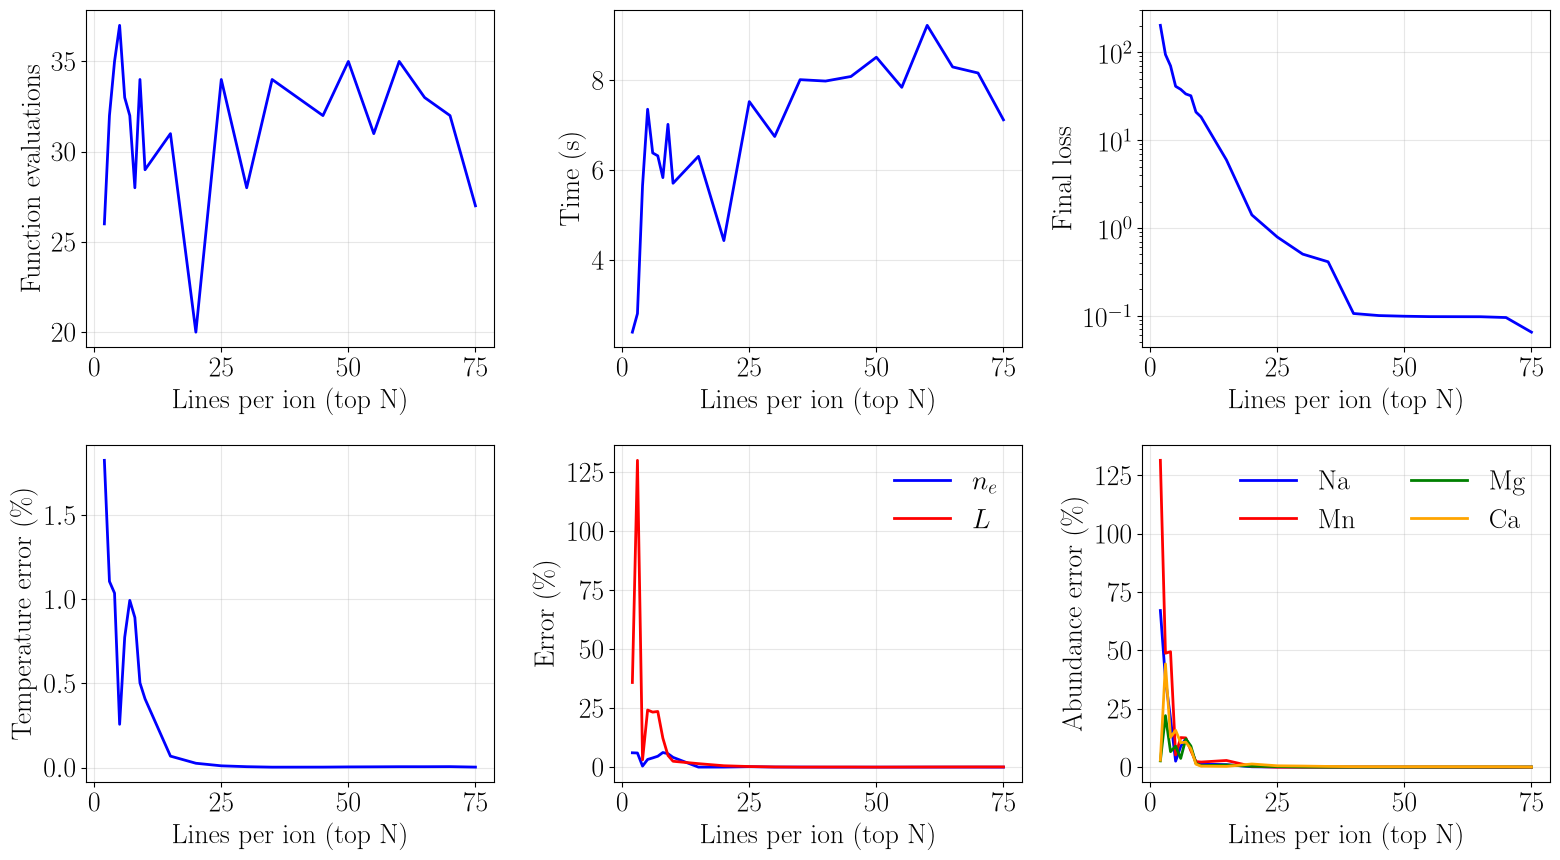

In [31]:
# ── Visualization: Line Scaling Results ───────────────────────────────
top_n_arr = np.array([d["top_n"] for d in line_scaling_data])
# With Enzyme, iterations = function evaluations (1 reverse pass per iteration)
fp_per_eval = 1  # Enzyme: 1 reverse pass per iteration
iters_arr = np.array([d["n_evaluations"] for d in line_scaling_data]) * fp_per_eval
times_arr = np.array([d["wall_time"] for d in line_scaling_data])
losses_arr = np.array([d["final_loss"] for d in line_scaling_data])
xlabel = "Lines per ion (top N)"

fig_ls, axes_ls = plt.subplots(2, 3, figsize=(16, 9))

# ── (a) Function evaluations vs number of lines ──
ax = axes_ls[0, 0]
ax.plot(top_n_arr, iters_arr, color="blue", linewidth=2)
ax.set_xlabel(xlabel)
ax.set_ylabel("Function evaluations")
ax.grid(True, alpha=0.3)

# ── (b) Wall-clock time vs number of lines ──
ax = axes_ls[0, 1]
ax.plot(top_n_arr, times_arr, color="blue", linewidth=2)
ax.set_xlabel(xlabel)
ax.set_ylabel("Time (s)")
ax.grid(True, alpha=0.3)

# ── (c) Final loss vs number of lines ──
ax = axes_ls[0, 2]
ax.semilogy(top_n_arr, losses_arr, color="blue", linewidth=2)
ax.set_xlabel(xlabel)
ax.set_ylabel("Final loss")
ax.grid(True, alpha=0.3)

# ── (d) Temperature recovery ──
ax = axes_ls[1, 0]
rec_T = np.array([d["recovered_T"] for d in line_scaling_data])
T_err_pct = np.abs(rec_T - line_scaling_true_T) / line_scaling_true_T * 100
ax.plot(top_n_arr, T_err_pct, color="blue", linewidth=2)
ax.set_xlabel(xlabel)
ax.set_ylabel("Temperature error (\\%)")
ax.grid(True, alpha=0.3)

# ── (e) Electron density & length recovery ──
ax = axes_ls[1, 1]
rec_ne = np.array([d["recovered_ne"] for d in line_scaling_data])
rec_L = np.array([d["recovered_L"] for d in line_scaling_data])
ne_err_pct = np.abs(rec_ne - line_scaling_true_ne) / line_scaling_true_ne * 100
L_err_pct = np.abs(rec_L - line_scaling_true_L) / line_scaling_true_L * 100
ax.plot(top_n_arr, ne_err_pct, 'b-', linewidth=2, label="$n_e$")
ax.plot(top_n_arr, L_err_pct, 'r-', linewidth=2, label="$L$")
ax.set_xlabel(xlabel)
ax.set_ylabel("Error (\\%)")
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)

# ── (f) Elemental ratio recovery ──
ax = axes_ls[1, 2]
elem_colors = {"Na": "blue", "Mn": "red", "Mg": "green", "Ca": "orange"}
for el, true_val in line_scaling_true_elements.items():
    rec_vals = np.array([d[f"recovered_{el}"] for d in line_scaling_data])
    rec_totals = np.zeros_like(rec_vals)
    for el2 in line_scaling_true_elements:
        rec_totals += np.array([d[f"recovered_{el2}"] for d in line_scaling_data])
    rec_frac = rec_vals / rec_totals
    true_frac = true_val / sum(line_scaling_true_elements.values())
    err_pct = np.abs(rec_frac - true_frac) / true_frac * 100
    ax.plot(top_n_arr, err_pct, color=elem_colors[el], linewidth=2, label=el)
ax.set_xlabel(xlabel)
ax.set_ylabel("Abundance error (\\%)")
ax.legend(frameon=False, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
# Save the combined line scaling figure
fig_ls.savefig("./figures/line_scaling_analysis.pdf", bbox_inches="tight")
print("Saved: line_scaling_analysis.pdf")

# Also save individual subplots for flexibility in the paper layout

# (a) Function evaluations to convergence
fig_a = plt.figure(figsize=(6, 4))
ax_a = fig_a.add_subplot(111)
ax_a.plot(top_n_arr, iters_arr, 'b-', linewidth=2)
ax_a.set_xlabel(xlabel)
ax_a.set_ylabel("Function evaluations")
ax_a.grid(True, alpha=0.3)
plt.tight_layout()
fig_a.savefig("./figures/line_scaling_a.pdf", bbox_inches="tight")
plt.close(fig_a)
print("Saved: line_scaling_a.pdf")

# (b) Wall-clock time
fig_b = plt.figure(figsize=(6, 4))
ax_b = fig_b.add_subplot(111)
ax_b.plot(top_n_arr, times_arr, 'b-', linewidth=2)
ax_b.set_xlabel(xlabel)
ax_b.set_ylabel("Time (s)")
ax_b.grid(True, alpha=0.3)
plt.tight_layout()
fig_b.savefig("./figures/line_scaling_b.pdf", bbox_inches="tight")
plt.close(fig_b)
print("Saved: line_scaling_b.pdf")

# (c) Final loss
fig_c = plt.figure(figsize=(6, 4))
ax_c = fig_c.add_subplot(111)
ax_c.semilogy(top_n_arr, losses_arr, 'b-', linewidth=2)
ax_c.set_xlabel(xlabel)
ax_c.set_ylabel("Final loss")
ax_c.grid(True, alpha=0.3)
plt.tight_layout()
fig_c.savefig("./figures/line_scaling_c.pdf", bbox_inches="tight")
plt.close(fig_c)
print("Saved: line_scaling_c.pdf")

# (d) Temperature recovery error
fig_d = plt.figure(figsize=(6, 4))
ax_d = fig_d.add_subplot(111)
ax_d.plot(top_n_arr, T_err_pct, 'b-', linewidth=2)
ax_d.set_xlabel(xlabel)
ax_d.set_ylabel("Temperature error (\\%)")
ax_d.grid(True, alpha=0.3)
plt.tight_layout()
fig_d.savefig("./figures/line_scaling_d.pdf", bbox_inches="tight")
plt.close(fig_d)
print("Saved: line_scaling_d.pdf")

# (e) Electron density & length recovery error
fig_e = plt.figure(figsize=(6, 4))
ax_e = fig_e.add_subplot(111)
ax_e.plot(top_n_arr, ne_err_pct, 'b-', linewidth=2, label="$n_e$")
ax_e.plot(top_n_arr, L_err_pct, 'r-', linewidth=2, label="$L$")
ax_e.set_xlabel(xlabel)
ax_e.set_ylabel("Error (\\%)")
ax_e.legend(frameon=False)
ax_e.grid(True, alpha=0.3)
plt.tight_layout()
fig_e.savefig("./figures/line_scaling_e.pdf", bbox_inches="tight")
plt.close(fig_e)
print("Saved: line_scaling_e.pdf")

# (f) Elemental ratio recovery error
fig_f = plt.figure(figsize=(6, 4))
ax_f = fig_f.add_subplot(111)
elem_colors = {"Na": "blue", "Mn": "red", "Mg": "green", "Ca": "orange"}
for el, true_val in line_scaling_true_elements.items():
    rec_vals = np.array([d[f"recovered_{el}"] for d in line_scaling_data])
    rec_totals = np.zeros_like(rec_vals)
    for el2 in line_scaling_true_elements:
        rec_totals += np.array([d[f"recovered_{el2}"] for d in line_scaling_data])
    rec_frac = rec_vals / rec_totals
    true_frac = true_val / sum(line_scaling_true_elements.values())
    err_pct = np.abs(rec_frac - true_frac) / true_frac * 100
    ax_f.plot(top_n_arr, err_pct, color=elem_colors[el], linewidth=2, label=el)
ax_f.set_xlabel(xlabel)
ax_f.set_ylabel("Abundance error (\\%)")
ax_f.legend(frameon=False, ncol=2)
ax_f.grid(True, alpha=0.3)
plt.tight_layout()
fig_f.savefig("./figures/line_scaling_f.pdf", bbox_inches="tight")
plt.close(fig_f)
print("Saved: line_scaling_f.pdf")

Saved: line_scaling_analysis.pdf
Saved: line_scaling_a.pdf
Saved: line_scaling_b.pdf
Saved: line_scaling_c.pdf
Saved: line_scaling_d.pdf
Saved: line_scaling_e.pdf
Saved: line_scaling_f.pdf


# 7. Effect of Fine Grid Resolution on Fitting Quality

In [33]:
# Restore the standard database
libskit.Database.bundled().activate(verbose=1)

# True plasma parameters
spf_true_elements = {"Na": 0.5, "Mn": 0.25, "Mg": 0.20, "Ca": 0.05}
spf_true_T = 8300.0       # K
spf_true_ne = 2.3e23      # m^-3
spf_true_L = 3e-4         # m

spf_instrument = libskit.GenericSpectrometer(0.05, 0.001)

# Fixed wavelength grid (auto-resolution handles the internal fine grid)
spf_wavelengths = np.arange(250, 900, 0.1)

# ── Step 1: Generate "true" spectrum with high grid density ──────────
libskit.set_fine_samples_per_fwhm(10)
true_model_spf = libskit.LTEModel(
    spf_true_elements, spf_true_T, spf_true_ne, spf_true_L
)
spec_true_spf = spf_instrument.calculate_spectrum(spf_wavelengths, true_model_spf)
spec_true_spf = spec_true_spf / np.max(spec_true_spf)

# Add a small amount of noise
np.random.seed(42)
noise_spf = np.random.normal(0, 0.001, len(spec_true_spf))
spec_true_spf = spec_true_spf + noise_spf

print(f"True spectrum: {len(spf_wavelengths)} points, fine_samples_per_fwhm = 10 (reference)")

# Compute the minimum Voigt FWHM across all lines (for reference in plots)
min_voigt_fwhm = true_model_spf.get_minimum_voigt_fwhm(spf_wavelengths)
fine_grid_spacing = true_model_spf.get_fine_grid_spacing(spf_wavelengths)
print(f"Minimum Voigt FWHM: {min_voigt_fwhm:.4f} nm")
print(f"Fine grid spacing: {fine_grid_spacing:.4f} nm")

# ── Step 2: Define fine_samples_per_fwhm values to sweep ─────────────
# Log-spaced SPF values → log-spaced fine grid spacings (dx = FWHM / SPF)
spf_values = np.logspace(np.log10(0.1), np.log10(5), 30).tolist()

# Cache configuration
spf_cache_dir = Path("../results")
spf_cache_dir.mkdir(parents=True, exist_ok=True)
force_rerun_spf = True

print(f"fine_samples_per_fwhm values to test: {spf_values}")

# Reset to default
libskit.set_fine_samples_per_fwhm(5)

Loading databases from: /home/cheg/Repos/libs_gd_paper_dlr/.venv/lib/python3.12/site-packages/libskit/data
✓ Databases loaded successfully!
  Lines: 2560 lines across 68 ions
  Ionization energies: 5847 entries
  Levels: 5331 ions
True spectrum: 6500 points, fine_samples_per_fwhm = 10 (reference)
Minimum Voigt FWHM: 0.0170 nm
Fine grid spacing: 0.0017 nm
fine_samples_per_fwhm values to test: [0.1, 0.11444192979749987, 0.1309695529577589, 0.14988408385201787, 0.17153023801955214, 0.19630251457582026, 0.22465238592158718, 0.2570965257847913, 0.2942262255504421, 0.33671817049027053, 0.3853467722879013, 0.4409982826186517, 0.5046869450026175, 0.5775734792970422, 0.6609862357060987, 0.7564454038379105, 0.8656907180165958, 0.9907131637760251, 1.1337912633831488, 1.2975326016911297, 1.4849213491270368, 1.699372647916051, 1.944794852726002, 2.2256607600620826, 2.54708912456075, 2.9149379478095683, 3.3359112398729085, 3.8176811992422626, 4.369028037929183, 5.000000000000001]


In [34]:
# ── Step 3: Run fitting at each fine_samples_per_fwhm ────────────────
spf_results = {}

# Initial guess (same as Section 1)
spf_guess_elements = {"Na": 0.25, "Mn": 0.25, "Mg": 0.25, "Ca": 0.1}
spf_guess_T = 10000.0
spf_guess_ne = 1e23
spf_guess_L = 1e-4

exp_spectrum_spf = libskit.Spectrum(spf_wavelengths, spec_true_spf)

for spf in spf_values:
    # Per-value cache file
    cache_file = spf_cache_dir / f"spf_sweep_{spf}.pkl"

    if cache_file.exists() and not force_rerun_spf:
        with open(cache_file, "rb") as f:
            entry = pickle.load(f)
        spf_results[spf] = entry
        print(f"[cached] spf={spf}  Δλ={entry['fine_grid_spacing']:.4f} nm  —  "
              f"loss={entry['final_loss']:.4e}, "
              f"T={entry['recovered_T']:.1f} K, time={entry['wall_time']:.3f} s")
        continue

    print(f"\n{'='*60}")
    print(f"fine_samples_per_fwhm = {spf}")
    print(f"{'='*60}")

    libskit.set_fine_samples_per_fwhm(spf)

    # Create model and experiment
    guess_model_spf = libskit.LTEModel(
        dict(spf_guess_elements), spf_guess_T, spf_guess_ne, spf_guess_L
    )

    # Query the actual fine grid spacing for this SPF value
    fine_grid_spacing = guess_model_spf.get_fine_grid_spacing(spf_wavelengths)
    print(f"  Fine grid spacing: {fine_grid_spacing:.4f} nm")

    exp_spf = libskit.Experiment(
        libskit.LossType.L2Loss,
        guess_model_spf,
        spf_instrument,
        exp_spectrum_spf,
        libskit.NormalizationType.AnalyticNorm,
    )

    # Run optimization
    t0 = time.perf_counter()
    opt_spf = libskit.Optimizer(exp_spf, parametrization=libskit.Parametrization.LOG_SOFTMAX_ALR)
    result = opt_spf.optimize(algorithm=nlopt.LD_LBFGS, max_eval=500, verbose=False, xtol_rel=1e-6)
    elapsed = time.perf_counter() - t0

    # Store results
    h = result["history"]
    entry = {
        "spf": spf,
        "fine_grid_spacing": fine_grid_spacing,
        "n_evaluations": result["n_evaluations"],
        "final_loss": result["final_loss"],
        "wall_time": elapsed,
        "history": h,
        "recovered_T": h["temperature"][-1],
        "recovered_ne": h["electron_density"][-1],
        "recovered_L": h["length"][-1],
    }
    for el in spf_true_elements:
        entry[f"recovered_{el}"] = h[el][-1]

    # Compute the final fitted spectrum
    final_model_spf = libskit.LTEModel(
        {el: h[el][-1] for el in spf_true_elements},
        h["temperature"][-1],
        h["electron_density"][-1],
        h["length"][-1],
    )
    fitted_spec = spf_instrument.calculate_spectrum(spf_wavelengths, final_model_spf)
    fitted_spec = fitted_spec / np.max(fitted_spec)
    entry["fitted_spectrum"] = fitted_spec

    # Save to cache
    with open(cache_file, "wb") as f:
        pickle.dump(entry, f)

    spf_results[spf] = entry

    print(f"  Iterations:    {entry['n_evaluations']}")
    print(f"  Wall time:     {elapsed:.3f} s")
    print(f"  Final loss:    {entry['final_loss']:.4e}")
    print(f"  T recovered:   {entry['recovered_T']:.1f} K  (true: {spf_true_T})")
    print(f"  ne recovered:  {entry['recovered_ne']:.2e}  (true: {spf_true_ne:.2e})")
    print(f"  L recovered:   {entry['recovered_L']:.3e}  (true: {spf_true_L:.3e})")
    for el in spf_true_elements:
        print(f"  {el}: {entry[f'recovered_{el}']:.4f}  (true: {spf_true_elements[el]:.4f})")
    print(f"  → cached to {cache_file}")

# Reset to default
libskit.set_fine_samples_per_fwhm(5)

# ── Summary table ────────────────────────────────────────────────────
print(f"\n{'SPF':>5} {'Δλ (nm)':>10} {'iters':>6} {'time(s)':>8} {'loss':>12} "
      f"{'T(K)':>8} {'ne':>10} {'L':>10}")
print("-" * 80)
for spf, d in spf_results.items():
    print(f"{spf:>5g} {d['fine_grid_spacing']:>10.4f} {d['n_evaluations']:>6} "
          f"{d['wall_time']:>8.3f} {d['final_loss']:>12.4e} "
          f"{d['recovered_T']:>8.1f} {d['recovered_ne']:>10.2e} {d['recovered_L']:>10.2e}")


fine_samples_per_fwhm = 0.1
  Fine grid spacing: 0.0893 nm
  Iterations:    36
  Wall time:     0.281 s
  Final loss:    4.0511e-01
  T recovered:   8286.2 K  (true: 8300.0)
  ne recovered:  2.54e+23  (true: 2.30e+23)
  L recovered:   2.397e-04  (true: 3.000e-04)
  Na: 0.4866  (true: 0.5000)
  Mn: 0.2495  (true: 0.2500)
  Mg: 0.2125  (true: 0.2000)
  Ca: 0.0515  (true: 0.0500)
  → cached to ../results/spf_sweep_0.1.pkl

fine_samples_per_fwhm = 0.11444192979749987
  Fine grid spacing: 0.0780 nm
  Iterations:    38
  Wall time:     0.329 s
  Final loss:    4.0511e-01
  T recovered:   8286.2 K  (true: 8300.0)
  ne recovered:  2.54e+23  (true: 2.30e+23)
  L recovered:   2.397e-04  (true: 3.000e-04)
  Na: 0.4866  (true: 0.5000)
  Mn: 0.2494  (true: 0.2500)
  Mg: 0.2125  (true: 0.2000)
  Ca: 0.0515  (true: 0.0500)
  → cached to ../results/spf_sweep_0.11444192979749987.pkl

fine_samples_per_fwhm = 0.1309695529577589
  Fine grid spacing: 0.0682 nm
  Iterations:    37
  Wall time:     0.300 s


<>:82: SyntaxWarning: invalid escape sequence '\D'
<>:82: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_17888/1685188076.py:82: SyntaxWarning: invalid escape sequence '\D'
  ax.axvline(min_voigt_fwhm, color="black", ls="--", alpha=0.5, label="$\Delta \lambda_{\min}$")


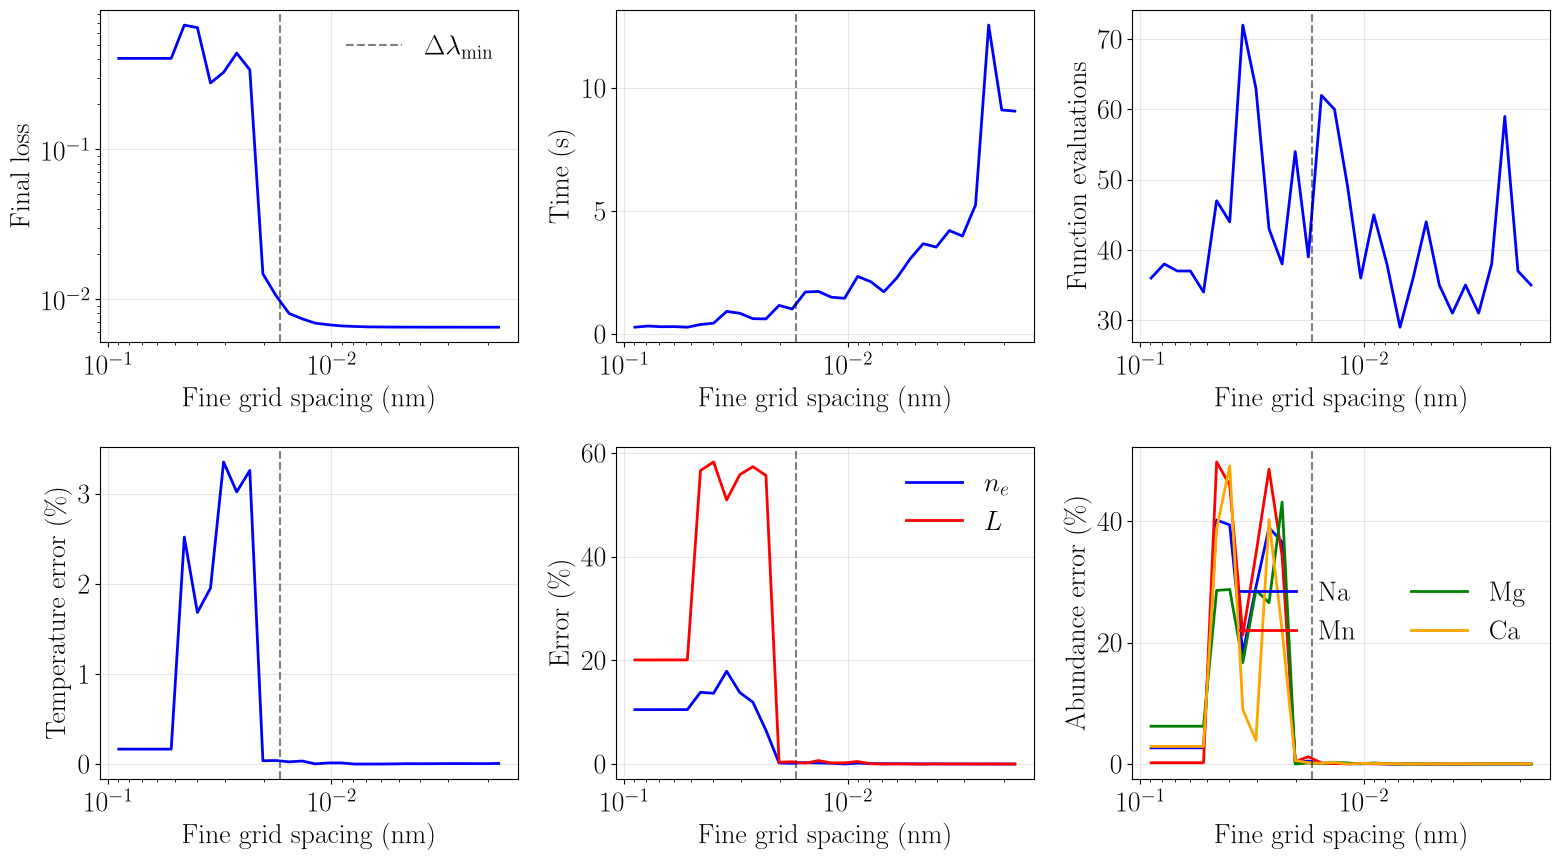

Max relative error in T:  3.35 %
Max relative error in ne: 17.91 %


In [35]:
# ── Visualization: Parameter recovery summary (2x3 grid) ─────────────
spf_arr = np.array(list(spf_results.keys()))
dx_arr = np.array([spf_results[s]["fine_grid_spacing"] for s in spf_arr])
fig_spf_summary, axes_spf = plt.subplots(2, 3, figsize=(16, 9))

# Function-evaluation multiplier for L-BFGS with 7 params
fp_per_eval = 1  # Enzyme: 1 reverse pass per iteration

xlabel = "Fine grid spacing (nm)"

# ── (a) Final loss ──
ax = axes_spf[0, 0]
ax.semilogy(dx_arr, [spf_results[s]["final_loss"] for s in spf_arr],
            'b-', linewidth=2)
ax.set_xlabel(xlabel)
ax.set_ylabel("Final loss")
ax.set_xscale("log")
ax.grid(True, alpha=0.3)

# ── (b) Wall-clock time ──
ax = axes_spf[0, 1]
ax.plot(dx_arr, [spf_results[s]["wall_time"] for s in spf_arr],
        'b-', linewidth=2)
ax.set_xlabel(xlabel)
ax.set_ylabel("Time (s)")
ax.set_xscale("log")
ax.grid(True, alpha=0.3)

# ── (c) Function evaluations ──
ax = axes_spf[0, 2]
ax.plot(dx_arr, [spf_results[s]["n_evaluations"] * fp_per_eval for s in spf_arr],
        'b-', linewidth=2)
ax.set_xlabel(xlabel)
ax.set_ylabel("Function evaluations")
ax.set_xscale("log")
ax.grid(True, alpha=0.3)

# ── (d) Temperature recovery error ──
ax = axes_spf[1, 0]
T_err = [abs(spf_results[s]["recovered_T"] - spf_true_T) / spf_true_T * 100
         for s in spf_arr]
ax.plot(dx_arr, T_err, 'b-', linewidth=2)
ax.set_xlabel(xlabel)
ax.set_ylabel("Temperature error (\\%)")
ax.set_xscale("log")
ax.grid(True, alpha=0.3)

# ── (e) Electron density & length recovery error ──
ax = axes_spf[1, 1]
ne_err = [abs(spf_results[s]["recovered_ne"] - spf_true_ne) / spf_true_ne * 100
          for s in spf_arr]
L_err = [abs(spf_results[s]["recovered_L"] - spf_true_L) / spf_true_L * 100
         for s in spf_arr]
ax.plot(dx_arr, ne_err, 'b-', linewidth=2, label="$n_e$")
ax.plot(dx_arr, L_err, 'r-', linewidth=2, label="$L$")
ax.set_xlabel(xlabel)
ax.set_ylabel("Error (\\%)")
ax.set_xscale("log")
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)

# ── (f) Elemental ratio recovery error ──
ax = axes_spf[1, 2]
elem_colors = {"Na": "blue", "Mn": "red", "Mg": "green", "Ca": "orange"}
for el, true_val in spf_true_elements.items():
    rec_vals = np.array([spf_results[s][f"recovered_{el}"] for s in spf_arr])
    rec_totals = np.zeros_like(rec_vals)
    for el2 in spf_true_elements:
        rec_totals += np.array([spf_results[s][f"recovered_{el2}"] for s in spf_arr])
    rec_frac = rec_vals / rec_totals
    true_frac = true_val / sum(spf_true_elements.values())
    err_pct = np.abs(rec_frac - true_frac) / true_frac * 100
    ax.plot(dx_arr, err_pct, color=elem_colors[el], linewidth=2, label=el)
ax.set_xlabel(xlabel)
ax.set_ylabel("Abundance error (\\%)")
ax.set_xscale("log")
ax.legend(frameon=False, ncol=2)
ax.grid(True, alpha=0.3)

# Mark the minimum Voigt FWHM and invert x-axis
for ax in axes_spf.flat:
    ax.axvline(min_voigt_fwhm, color="black", ls="--", alpha=0.5, label="$\Delta \lambda_{\min}$")
    ax.invert_xaxis()
axes_spf[0, 0].legend(frameon=False)

plt.tight_layout()
plt.show()

print(f"Max relative error in T:  {max(T_err):.2f} %")
print(f"Max relative error in ne: {max(ne_err):.2f} %")

In [36]:
# ── Save fine grid resolution study figures ───────────────────────────
dx_arr = np.array([spf_results[s]["fine_grid_spacing"] for s in spf_arr])
xlabel = "Fine grid spacing (nm)"
_vline_kw = dict(color="black", ls="--", alpha=0.5)

# Function-evaluation multiplier for L-BFGS with 7 params
fp_per_eval = 1  # Enzyme: 1 reverse pass per iteration

# Save the combined parameter recovery figure
fig_spf_summary.savefig("./figures/spf_analysis.pdf", bbox_inches="tight")
print("Saved: spf_analysis.pdf")

# Save individual subplots for paper layout flexibility

# (a) Final loss
fig_a = plt.figure(figsize=(6, 4))
ax_a = fig_a.add_subplot(111)
ax_a.semilogy(dx_arr, [spf_results[s]["final_loss"] for s in spf_arr],
              'b-', linewidth=2)
ax_a.set_xlabel(xlabel)
ax_a.set_ylabel("Final loss")
ax_a.set_xscale("log")
ax_a.axvline(min_voigt_fwhm, **_vline_kw, label="$\Delta \lambda_{\min}$")
ax_a.invert_xaxis()
ax_a.legend(frameon=False)
ax_a.grid(True, alpha=0.3)
plt.tight_layout()
fig_a.savefig("./figures/spf_a_loss.pdf", bbox_inches="tight")
plt.close(fig_a)
print("Saved: spf_a_loss.pdf")

# (b) Wall-clock time
fig_b = plt.figure(figsize=(6, 4))
ax_b = fig_b.add_subplot(111)
ax_b.plot(dx_arr, [spf_results[s]["wall_time"] for s in spf_arr],
          'b-', linewidth=2)
ax_b.set_xlabel(xlabel)
ax_b.set_ylabel("Time (s)")
ax_b.set_xscale("log")
ax_b.axvline(min_voigt_fwhm, **_vline_kw, label="$\Delta \lambda_{\min}$")
ax_b.invert_xaxis()
ax_b.legend(frameon=False)
ax_b.grid(True, alpha=0.3)
plt.tight_layout()
fig_b.savefig("./figures/spf_b_time.pdf", bbox_inches="tight")
plt.close(fig_b)
print("Saved: spf_b_time.pdf")

# (c) Function evaluations
fig_c = plt.figure(figsize=(6, 4))
ax_c = fig_c.add_subplot(111)
ax_c.plot(dx_arr, [spf_results[s]["n_evaluations"] * fp_per_eval for s in spf_arr],
          'b-', linewidth=2)
ax_c.set_xlabel(xlabel)
ax_c.set_ylabel("Function evaluations")
ax_c.set_xscale("log")
ax_c.axvline(min_voigt_fwhm, **_vline_kw, label="$\Delta \lambda_{\min}$")
ax_c.invert_xaxis()
ax_c.legend(frameon=False)
ax_c.grid(True, alpha=0.3)
plt.tight_layout()
fig_c.savefig("./figures/spf_c_iters.pdf", bbox_inches="tight")
plt.close(fig_c)
print("Saved: spf_c_iters.pdf")

# (d) Temperature recovery error
fig_d = plt.figure(figsize=(6, 4))
ax_d = fig_d.add_subplot(111)
ax_d.plot(dx_arr, T_err, 'b-', linewidth=2)
ax_d.set_xlabel(xlabel)
ax_d.set_ylabel("Temperature error (\\%)")
ax_d.set_xscale("log")
ax_d.axvline(min_voigt_fwhm, **_vline_kw, label="$\Delta \lambda_{\min}$")
ax_d.invert_xaxis()
ax_d.legend(frameon=False)
ax_d.grid(True, alpha=0.3)
plt.tight_layout()
fig_d.savefig("./figures/spf_d_temp.pdf", bbox_inches="tight")
plt.close(fig_d)
print("Saved: spf_d_temp.pdf")

# (e) Electron density & length recovery error
fig_e = plt.figure(figsize=(6, 4))
ax_e = fig_e.add_subplot(111)
ax_e.plot(dx_arr, ne_err, 'b-', linewidth=2, label="$n_e$")
ax_e.plot(dx_arr, L_err, 'r-', linewidth=2, label="$L$")
ax_e.set_xlabel(xlabel)
ax_e.set_ylabel("Error (\\%)")
ax_e.set_xscale("log")
ax_e.axvline(min_voigt_fwhm, **_vline_kw, label="$\Delta \lambda_{\min}$")
ax_e.invert_xaxis()
ax_e.legend(frameon=False)
ax_e.grid(True, alpha=0.3)
plt.tight_layout()
fig_e.savefig("./figures/spf_e_ne_L.pdf", bbox_inches="tight")
plt.close(fig_e)
print("Saved: spf_e_ne_L.pdf")

# (f) Elemental ratio recovery error
fig_f = plt.figure(figsize=(6, 4))
ax_f = fig_f.add_subplot(111)
for el, true_val in spf_true_elements.items():
    rec_vals = np.array([spf_results[s][f"recovered_{el}"] for s in spf_arr])
    rec_totals = np.zeros_like(rec_vals)
    for el2 in spf_true_elements:
        rec_totals += np.array([spf_results[s][f"recovered_{el2}"] for s in spf_arr])
    rec_frac = rec_vals / rec_totals
    true_frac = true_val / sum(spf_true_elements.values())
    err_pct = np.abs(rec_frac - true_frac) / true_frac * 100
    ax_f.plot(dx_arr, err_pct, color=elem_colors[el], linewidth=2, label=el)
ax_f.set_xlabel(xlabel)
ax_f.set_ylabel("Abundance error (\\%)")
ax_f.set_xscale("log")
ax_f.axvline(min_voigt_fwhm, **_vline_kw, label="$\Delta \lambda_{\min}$")
ax_f.invert_xaxis()
ax_f.legend(frameon=False, ncol=1)
ax_f.grid(True, alpha=0.3)
plt.tight_layout()
fig_f.savefig("./figures/spf_f_elements.pdf", bbox_inches="tight")
plt.close(fig_f)
print("Saved: spf_f_elements.pdf")

<>:23: SyntaxWarning: invalid escape sequence '\D'
<>:40: SyntaxWarning: invalid escape sequence '\D'
<>:57: SyntaxWarning: invalid escape sequence '\D'
<>:73: SyntaxWarning: invalid escape sequence '\D'
<>:90: SyntaxWarning: invalid escape sequence '\D'
<>:114: SyntaxWarning: invalid escape sequence '\D'
<>:23: SyntaxWarning: invalid escape sequence '\D'
<>:40: SyntaxWarning: invalid escape sequence '\D'
<>:57: SyntaxWarning: invalid escape sequence '\D'
<>:73: SyntaxWarning: invalid escape sequence '\D'
<>:90: SyntaxWarning: invalid escape sequence '\D'
<>:114: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_17888/2013584932.py:23: SyntaxWarning: invalid escape sequence '\D'
  ax_a.axvline(min_voigt_fwhm, **_vline_kw, label="$\Delta \lambda_{\min}$")
/tmp/ipykernel_17888/2013584932.py:40: SyntaxWarning: invalid escape sequence '\D'
  ax_b.axvline(min_voigt_fwhm, **_vline_kw, label="$\Delta \lambda_{\min}$")
/tmp/ipykernel_17888/2013584932.py:57: SyntaxWarning: invalid esca

Saved: spf_analysis.pdf
Saved: spf_a_loss.pdf
Saved: spf_b_time.pdf
Saved: spf_c_iters.pdf
Saved: spf_d_temp.pdf
Saved: spf_e_ne_L.pdf
Saved: spf_f_elements.pdf


# 8. Extended Element Fit: Including Extra Rock-Forming Elements

In [37]:
# ── Extended element guess model ──────────────────────────────────────
# True sample has only Na, Mn, Mg, Ca.
# We add common rock-forming elements to the guess (all absent from truth).

ext_true_elements = {"Na": 0.5, "Mn": 0.25, "Mg": 0.20, "Ca": 0.05}

# Extra elements: give each a small uniform initial guess
extra_elements = ["Si", "Al", "Fe", "K"]
all_elements = list(ext_true_elements.keys()) + extra_elements
n_el = len(all_elements)
equal_frac = 1.0 / n_el

ext_guess_elements = {el: equal_frac for el in all_elements}

print(f"True elements: {list(ext_true_elements.keys())}")
print(f"Guess elements ({n_el} total): {list(ext_guess_elements.keys())}")
print(f"Initial guess fraction per element: {equal_frac:.4f}")

# Build guess model
ext_guess_model = libskit.LTEModel(
    ext_guess_elements,
    10000.0,   # Wrong temperature (true: 8300)
    1e23,      # Wrong density (true: 2.3e23)
    1e-4       # Wrong length (true: 3e-4)
)

# Use the same experimental spectrum from Section 1
ext_experiment = libskit.Experiment(
    libskit.LossType.L2Loss,
    ext_guess_model,
    instrument,
    experimental_spectrum,
    libskit.NormalizationType.AnalyticNorm
)

True elements: ['Na', 'Mn', 'Mg', 'Ca']
Guess elements (8 total): ['Na', 'Mn', 'Mg', 'Ca', 'Si', 'Al', 'Fe', 'K']
Initial guess fraction per element: 0.1250


In [38]:
# ── Run optimization ──────────────────────────────────────────────────
ext_optimizer = libskit.Optimizer(ext_experiment, parametrization=libskit.Parametrization.LOG_SOFTMAX_ALR)
ext_results = ext_optimizer.optimize(algorithm=nlopt.LD_LBFGS, max_eval=500, verbose=True)

Optimizer: Limited-memory BFGS (L-BFGS) (local, derivative-based)
Parameters (11): ['temperature', 'electron_density', 'length', 'Al', 'Ca', 'Fe', 'K', 'Mg', 'Mn', 'Na', 'Si']
Max evaluations: 500
Iter    1: Loss=2.7410e+02  temperature=10000  electron_density=1.00e+23  length=1.000e-04  Al=0.1250  Ca=0.1250  Fe=0.1250  K=0.1250  Mg=0.1250  Mn=0.1250  Na=0.1250  Si=0.1250
Iter    2: Loss=3.1782e+02  temperature=5000  electron_density=1.16e+23  length=1.066e-04  Al=0.1230  Ca=0.1243  Fe=0.1235  K=0.1238  Mg=0.1298  Mn=0.1258  Na=0.1250  Si=0.1248
Iter    3: Loss=1.7593e+02  temperature=7632  electron_density=1.06e+23  length=1.025e-04  Al=0.1242  Ca=0.1247  Fe=0.1244  K=0.1245  Mg=0.1269  Mn=0.1253  Na=0.1250  Si=0.1249
Iter   11: Loss=5.6576e+01  temperature=8542  electron_density=2.62e+23  length=1.640e-04  Al=0.0469  Ca=0.0778  Fe=0.1062  K=0.0842  Mg=0.2800  Mn=0.1620  Na=0.1350  Si=0.1079
Iter   21: Loss=3.3716e+00  temperature=8123  electron_density=2.25e+23  length=2.317e-04  Al=

In [39]:
# ── Summary ───────────────────────────────────────────────────────────
ext_h = ext_results['history']

print("=" * 80)
print("EXTENDED ELEMENT FIT — SUMMARY")
print("=" * 80)
print(f"Iterations: {ext_results['n_evaluations']}")
print(f"Initial loss: {ext_h['loss'][0]:.2e}")
print(f"Final loss: {ext_results['final_loss']:.2e}")

ext_final_T = ext_h['temperature'][-1]
ext_final_ne = ext_h['electron_density'][-1]
ext_final_L = ext_h['length'][-1]

print(f"\nPlasma parameters:")
print(f"  Temperature:      {ext_final_T:.3f} K  (true: 8300.0 K,   err: {abs(ext_final_T-8300)/8300*100:.3f}%)")
print(f"  Electron density: {ext_final_ne:.4e} m^-3  (true: 2.3e+23,  err: {abs(ext_final_ne-2.3e23)/2.3e23*100:.3f}%)")
print(f"  Length:           {ext_final_L:.4e} m  (true: 3.0e-04,  err: {abs(ext_final_L-3e-4)/3e-4*100:.3f}%)")

# Element recovery
ext_total = sum(ext_h[el][-1] for el in all_elements)
print(f"\nElement concentrations (normalized to sum=1):")
print(f"  {'Element':>8} {'Recovered':>10} {'True':>8} {'Error':>8}")
print(f"  {'-'*40}")
for el in all_elements:
    rec_frac = ext_h[el][-1] / ext_total
    true_frac = ext_true_elements.get(el, 0.0)
    if true_frac > 0:
        err_str = f"{abs(rec_frac - true_frac)/true_frac*100:.2f}%"
    else:
        err_str = f"(abs: {rec_frac:.4f})"
    marker = " *" if el in ext_true_elements else ""
    print(f"  {el:>8} {rec_frac:>10.6f} {true_frac:>8.4f} {err_str:>12}{marker}")

print(f"\n  * = element present in true sample")
print(f"  Sum of absent-element fractions: {sum(ext_h[el][-1]/ext_total for el in extra_elements):.6f}")

EXTENDED ELEMENT FIT — SUMMARY
Iterations: 54
Initial loss: 2.74e+02
Final loss: 6.51e-02

Plasma parameters:
  Temperature:      8299.751 K  (true: 8300.0 K,   err: 0.003%)
  Electron density: 2.3002e+23 m^-3  (true: 2.3e+23,  err: 0.008%)
  Length:           2.9979e-04 m  (true: 3.0e-04,  err: 0.070%)

Element concentrations (normalized to sum=1):
   Element  Recovered     True    Error
  ----------------------------------------
        Na   0.499872   0.5000        0.03% *
        Mn   0.249989   0.2500        0.00% *
        Mg   0.200096   0.2000        0.05% *
        Ca   0.050025   0.0500        0.05% *
        Si   0.000011   0.0000 (abs: 0.0000)
        Al   0.000000   0.0000 (abs: 0.0000)
        Fe   0.000007   0.0000 (abs: 0.0000)
         K   0.000000   0.0000 (abs: 0.0000)

  * = element present in true sample
  Sum of absent-element fractions: 0.000018


/tmp/ipykernel_17888/2070483787.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


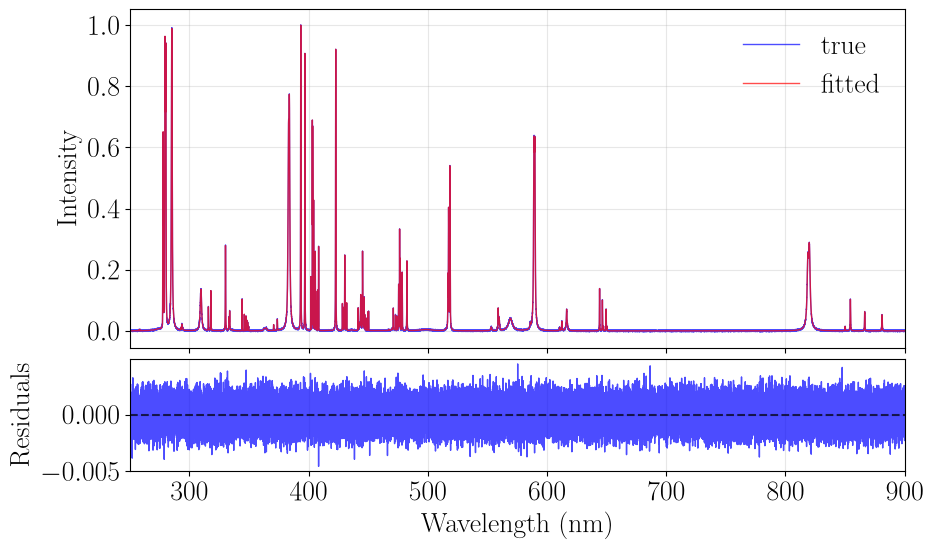

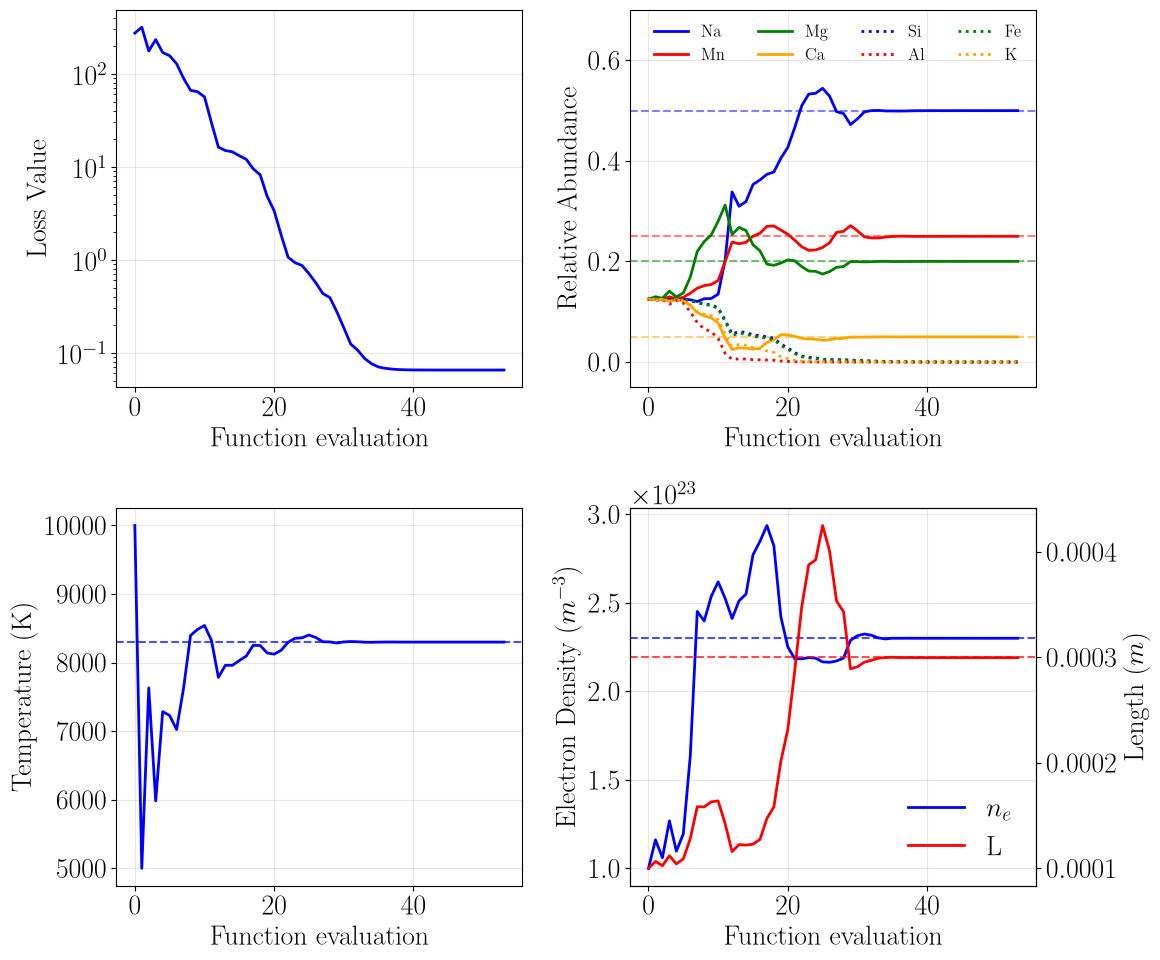

In [40]:
# ── Visualization: Extended Element Fit ────────────────────────────────
ext_h = ext_results['history']

# Update ext_guess_model with final values for spectrum plot
ext_guess_model.temperature = ext_h['temperature'][-1]
ext_guess_model.electron_density = ext_h['electron_density'][-1]
ext_guess_model.length = ext_h['length'][-1]
for el in all_elements:
    ext_guess_model.set_element_ratio(el, ext_h[el][-1])
ext_final_model = ext_guess_model

# ── Spectrum + Residuals ──
fig_ext_spec, (ax_s, ax_r) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                                            gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

ax_s.plot(wavelengths, true_spectrum, 'b-', linewidth=1, alpha=0.7, label='true')
ext_final_spectrum = instrument.calculate_spectrum(wavelengths, ext_final_model)
ax_s.plot(wavelengths, ext_final_spectrum / np.max(ext_final_spectrum), 'r-', linewidth=1, alpha=0.7, label='fitted')
ax_s.set_ylabel('Intensity')
ax_s.legend(frameon=False)
ax_s.grid(True, alpha=0.3)
ax_s.set_xlim(250, 900)
ax_s.tick_params(axis='x', labelbottom=False)

ext_residuals = ext_final_spectrum / np.max(ext_final_spectrum) - true_spectrum
ax_r.plot(wavelengths, ext_residuals, 'b-', linewidth=1, alpha=0.7)
ax_r.axhline(y=0, color='black', linestyle='--', alpha=0.7)
ax_r.set_xlabel('Wavelength (nm)')
ax_r.set_ylabel('Residuals')
ax_r.grid(True, alpha=0.3)
ax_r.set_xlim(250, 900)
plt.tight_layout()
plt.show()

# ── Parameter Evolution (2x2) ──
fig_ext_params, axes = plt.subplots(2, 2, figsize=(12, 10))

# (a) Loss
loss_iters = np.arange(len(ext_h['loss'])) 
axes[0, 0].semilogy(loss_iters, ext_h['loss'], 'b-', linewidth=2)
axes[0, 0].set_xlabel('Function evaluation')
axes[0, 0].set_ylabel('Loss Value')
axes[0, 0].grid(True, alpha=0.3)

# (b) Element ratios — use same colors as Section 1 for the 4 true elements
param_iters = np.arange(len(ext_h['temperature'])) 
true_el_colors = {'Na': 'blue', 'Mn': 'red', 'Mg': 'green', 'Ca': 'orange'}

# Plot true elements with solid lines
for el in ext_true_elements:
    axes[0, 1].plot(param_iters[:len(ext_h[el])], ext_h[el],
                    color=true_el_colors[el], linewidth=2, linestyle='-', label=el)
    axes[0, 1].axhline(y=ext_true_elements[el], color=true_el_colors[el], linestyle='--', alpha=0.5)

# Plot extra elements with dashed lines, cycling through the same 4 colors
extra_colors = list(true_el_colors.values())
for i, el in enumerate(extra_elements):
    axes[0, 1].plot(param_iters[:len(ext_h[el])], ext_h[el],
                    color=extra_colors[i % len(extra_colors)], linewidth=2.0,
                    linestyle=':', label=el)

axes[0, 1].set_xlabel('Function evaluation')
axes[0, 1].set_ylabel('Relative Abundance')
axes[0, 1].legend(frameon=False, ncol=4, fontsize=12)
axes[0, 1].set_ylim(-0.05, 0.7)
axes[0, 1].grid(True, alpha=0.3)

# (c) Temperature
axes[1, 0].plot(param_iters, ext_h['temperature'], 'b-', linewidth=2)
axes[1, 0].axhline(y=8300.0, color='blue', linestyle='--', alpha=0.7)
axes[1, 0].set_xlabel('Function evaluation')
axes[1, 0].set_ylabel('Temperature (K)')
axes[1, 0].grid(True, alpha=0.3)

# (d) Electron density & Length
ax_ne = axes[1, 1]
ax_l = ax_ne.twinx()
l1 = ax_ne.plot(param_iters, ext_h['electron_density'], 'b-', linewidth=2, label='$n_e$')
ax_ne.axhline(y=2.3e23, color='blue', linestyle='--', alpha=0.7)
l2 = ax_l.plot(param_iters, ext_h['length'], 'red', linewidth=2, label='L')
ax_l.axhline(y=3e-4, color='red', linestyle='--', alpha=0.7)
ax_ne.set_xlabel('Function evaluation')
ax_ne.set_ylabel('Electron Density ($m^{-3}$)')
ax_l.set_ylabel('Length ($m$)')
ax_ne.grid(True, alpha=0.3)
lines = l1 + l2
ax_ne.legend(lines, [l.get_label() for l in lines], loc='lower right', frameon=False)

plt.tight_layout()
plt.show()

In [41]:
# Save extended element fit figures
fig_ext_params.savefig('./figures/extended_element_params.pdf', bbox_inches='tight')
fig_ext_spec.savefig('./figures/extended_element_spectrum.pdf', bbox_inches='tight')
print("Saved: extended_element_params.pdf, extended_element_spectrum.pdf")

# Save individual subplots for paper layout
ext_h = ext_results['history']

# (a) Loss
fig_a = plt.figure(figsize=(6, 4))
ax_a = fig_a.add_subplot(111)
loss_iters = np.arange(len(ext_h['loss']))
ax_a.semilogy(loss_iters, ext_h['loss'], 'b-', linewidth=2)
ax_a.set_xlabel('Function evaluation')
ax_a.set_ylabel('Loss Value')
ax_a.grid(True, alpha=0.3)
plt.tight_layout()
fig_a.savefig('./figures/extended_element_params_a.pdf', bbox_inches='tight')
plt.close(fig_a)
print("Saved: extended_element_params_a.pdf")

# (b) Element ratios
fig_b = plt.figure(figsize=(6, 4))
ax_b = fig_b.add_subplot(111)
param_iters = np.arange(len(ext_h['temperature']))
true_el_colors = {'Na': 'blue', 'Mn': 'red', 'Mg': 'green', 'Ca': 'orange'}
for el in ext_true_elements:
    ax_b.plot(param_iters[:len(ext_h[el])], ext_h[el],
              color=true_el_colors[el], linewidth=2, linestyle='-', label=el)
    ax_b.axhline(y=ext_true_elements[el], color=true_el_colors[el], linestyle='--', alpha=0.5)
extra_colors = list(true_el_colors.values())
for i, el in enumerate(extra_elements):
    ax_b.plot(param_iters[:len(ext_h[el])], ext_h[el],
              color=extra_colors[i % len(extra_colors)], linewidth=2.0,
              linestyle=':', label=el)
ax_b.set_xlabel('Function evaluation')
ax_b.set_ylabel('Relative Abundance')
ax_b.legend(frameon=False, ncol=4, fontsize=12)
ax_b.set_ylim(-0.05, 0.7)
ax_b.grid(True, alpha=0.3)
plt.tight_layout()
fig_b.savefig('./figures/extended_element_params_b.pdf', bbox_inches='tight')
plt.close(fig_b)
print("Saved: extended_element_params_b.pdf")

# (c) Temperature
fig_c = plt.figure(figsize=(6, 4))
ax_c = fig_c.add_subplot(111)
ax_c.plot(param_iters, ext_h['temperature'], 'b-', linewidth=2)
ax_c.axhline(y=8300.0, color='blue', linestyle='--', alpha=0.7)
ax_c.set_xlabel('Function evaluation')
ax_c.set_ylabel('Temperature (K)')
ax_c.grid(True, alpha=0.3)
plt.tight_layout()
fig_c.savefig('./figures/extended_element_params_c.pdf', bbox_inches='tight')
plt.close(fig_c)
print("Saved: extended_element_params_c.pdf")

# (d) Electron density & Length
fig_d = plt.figure(figsize=(6, 4))
ax_ne_d = fig_d.add_subplot(111)
ax_l_d = ax_ne_d.twinx()
l1 = ax_ne_d.plot(param_iters, ext_h['electron_density'], 'b-', linewidth=2, label='$n_e$')
ax_ne_d.axhline(y=2.3e23, color='blue', linestyle='--', alpha=0.7)
l2 = ax_l_d.plot(param_iters, ext_h['length'], 'red', linewidth=2, label='L')
ax_l_d.axhline(y=3e-4, color='red', linestyle='--', alpha=0.7)
ax_ne_d.set_xlabel('Function evaluation')
ax_ne_d.set_ylabel('Electron Density ($m^{-3}$)')
ax_l_d.set_ylabel('Length ($m$)')
ax_ne_d.grid(True, alpha=0.3)
lines = l1 + l2
ax_ne_d.legend(lines, [l.get_label() for l in lines], loc='lower right', frameon=False)
plt.tight_layout()
fig_d.savefig('./figures/extended_element_params_d.pdf', bbox_inches='tight')
plt.close(fig_d)
print("Saved: extended_element_params_d.pdf")

Saved: extended_element_params.pdf, extended_element_spectrum.pdf
Saved: extended_element_params_a.pdf
Saved: extended_element_params_b.pdf
Saved: extended_element_params_c.pdf
Saved: extended_element_params_d.pdf


# 9. Local Algorithm Comparison

In [42]:
results_dir = "./results"
os.makedirs(results_dir, exist_ok=True)

force_rerun_local = True
force_rerun_local_names = set()  # e.g. {"COBYLA", "BOBYQA"}

# ── Algorithm registry: all local NLopt algorithms ────────────────────
# Gradient-based (LD_*): need gradient → n_params function evals per step
# Derivative-free (LN_*): 1 function eval per step
LOCAL_ALGORITHMS = {
    # Gradient-based
    "L-BFGS":     (nlopt.LD_LBFGS,                   500),
    "SLSQP":      (nlopt.LD_SLSQP,                   500),
    "MMA":        (nlopt.LD_MMA,                      500),
    "CCSAQ":      (nlopt.LD_CCSAQ,                    500),
    "TNewton":    (nlopt.LD_TNEWTON_PRECOND_RESTART,  500),
    "VAR1":       (nlopt.LD_VAR1,                     500),
    "VAR2":       (nlopt.LD_VAR2,                     500),
    # Derivative-free
    "Nelder-Mead": (nlopt.LN_NELDERMEAD,  2000),
    "COBYLA":      (nlopt.LN_COBYLA,      2000),
    "BOBYQA":      (nlopt.LN_BOBYQA,      2000),
    "NEWUOA":      (nlopt.LN_NEWUOA_BOUND, 2000),
    "PRAXIS":      (nlopt.LN_PRAXIS,      2000),
    "Sbplx":       (nlopt.LN_SBPLX,       2000),
}

# Which algorithms are gradient-based (cost = n_params per step)
GRADIENT_BASED = {"L-BFGS", "SLSQP", "MMA", "CCSAQ", "TNewton", "VAR1", "VAR2"}

def _local_cache_path(name: str) -> str:
    slug = name.lower().replace("-", "_").replace(" ", "_")
    return os.path.join(results_dir, f"local_algo_{slug}.pkl")

# ── Run / load each algorithm ────────────────────────────────────────
local_algo_results = {}

for i, (name, (algo_const, max_eval)) in enumerate(LOCAL_ALGORITHMS.items(), 1):
    cache = _local_cache_path(name)
    need_run = force_rerun_local or (name in force_rerun_local_names) or not os.path.exists(cache)

    if not need_run:
        with open(cache, "rb") as f:
            local_algo_results[name] = pickle.load(f)
        ts = local_algo_results[name].get("timestamp", "?")
        n  = local_algo_results[name]["n_evaluations"]
        fl = local_algo_results[name]["final_loss"]
        wt = local_algo_results[name].get("wall_time", None)
        wt_str = f", wall={wt:.3f}s" if wt is not None else ""
        print(f"[{i}/{len(LOCAL_ALGORITHMS)}] {name:15} — loaded from cache  "
              f"({n} evals, loss={fl:.4e}{wt_str}, cached {ts})")
        continue

    print(f"[{i}/{len(LOCAL_ALGORITHMS)}] {name:15} — running (max_eval={max_eval})…")
    model_i = libskit.LTEModel(
        {"Na": 0.25, "Mn": 0.25, "Mg": 0.25, "Ca": 0.25},
        10000.0, 1e23, 1e-4,
    )
    exp_i = libskit.Experiment(
        libskit.LossType.L2Loss, model_i, instrument,
        experimental_spectrum, libskit.NormalizationType.AnalyticNorm,
    )
    opt_i = libskit.Optimizer(exp_i, parametrization=libskit.Parametrization.LOG_SOFTMAX_ALR)
    t0 = time.perf_counter()
    res = opt_i.optimize(algorithm=algo_const, max_eval=max_eval, verbose=False)
    res["wall_time"] = time.perf_counter() - t0
    res["timestamp"] = datetime.now().isoformat()

    with open(cache, "wb") as f:
        pickle.dump(res, f)

    local_algo_results[name] = res
    print(f"{'':19} ✓ {res['n_evaluations']} evals, "
          f"loss={res['final_loss']:.4e}, wall={res['wall_time']:.3f}s  → saved to {cache}")

print(f"\nAll {len(LOCAL_ALGORITHMS)} local algorithms ready.")

[1/13] L-BFGS          — running (max_eval=500)…
                    ✓ 28 evals, loss=6.5130e-02, wall=8.017s  → saved to ./results/local_algo_l_bfgs.pkl
[2/13] SLSQP           — running (max_eval=500)…
                    ✓ 38 evals, loss=6.5129e-02, wall=7.885s  → saved to ./results/local_algo_slsqp.pkl
[3/13] MMA             — running (max_eval=500)…
                    ✓ 115 evals, loss=6.8633e-02, wall=29.506s  → saved to ./results/local_algo_mma.pkl
[4/13] CCSAQ           — running (max_eval=500)…
                    ✓ 103 evals, loss=8.6480e-02, wall=27.525s  → saved to ./results/local_algo_ccsaq.pkl
[5/13] TNewton         — running (max_eval=500)…
                    ✓ 92 evals, loss=6.5212e-02, wall=24.333s  → saved to ./results/local_algo_tnewton.pkl
[6/13] VAR1            — running (max_eval=500)…
                    ✓ 58 evals, loss=6.5128e-02, wall=14.455s  → saved to ./results/local_algo_var1.pkl
[7/13] VAR2            — running (max_eval=500)…
                    ✓ 58 ev

In [43]:
# ── Summary table ─────────────────────────────────────────────────────
print(f"{'Algorithm':15} {'Type':>12} {'Evals':>8} {'Func Evals':>12} "
      f"{'Wall (s)':>10} {'ms/eval':>10} {'Final Loss':>14} {'Best Loss':>14}")
print("─" * 100)
for name, res in local_algo_results.items():
    h = res["history"]
    best = min(h["loss"])
    n_evals = res["n_evaluations"]
    n_func = n_evals 
    kind = "gradient" if name in GRADIENT_BASED else "deriv-free"
    wt = res.get("wall_time", float("nan"))
    ms_per_eval = (wt / n_func * 1000) if n_evals > 0 else float("nan")
    print(f"{name:15} {kind:>12} {n_evals:>8} {n_func:>12} "
          f"{wt:>10.3f} {ms_per_eval:>10.2f} {res['final_loss']:>14.4e} {best:>14.4e}")

Algorithm               Type    Evals   Func Evals   Wall (s)    ms/eval     Final Loss      Best Loss
────────────────────────────────────────────────────────────────────────────────────────────────────
L-BFGS              gradient       28           28      8.017     286.33     6.5130e-02     6.5130e-02
SLSQP               gradient       38           38      7.885     207.51     6.5129e-02     6.5129e-02
MMA                 gradient      115          115     29.506     256.57     6.8633e-02     6.8633e-02
CCSAQ               gradient      103          103     27.525     267.24     8.6480e-02     8.6480e-02
TNewton             gradient       92           92     24.333     264.49     6.5212e-02     6.5212e-02
VAR1                gradient       58           58     14.455     249.22     6.5128e-02     6.5128e-02
VAR2                gradient       58           58     14.589     251.54     6.5128e-02     6.5128e-02
Nelder-Mead       deriv-free      367          367     18.252      49.73   

In [44]:
# ── Best parameters per algorithm ──────────────────────────────────────
true_values = {
    "Na": 0.5, "Mn": 0.25, "Mg": 0.20, "Ca": 0.05,
    "temperature": 8300.0, "electron_density": 2.3e23, "length": 3e-4,
}

param_names = [k for k in list(local_algo_results.values())[0]["history"].keys()
               if k not in ("loss", "iteration", "column_density")]

header = f"{'Algorithm':15}"
for p in param_names:
    width = max(len(p), 10)
    header += f" {p:>{width}}"
print(header)
print("─" * len(header))

row = f"{'TRUE':15}"
for p in param_names:
    width = max(len(p), 10)
    val = true_values.get(p, float("nan"))
    if val > 1e4:
        row += f" {val:>{width}.3e}"
    else:
        row += f" {val:>{width}.4f}"
print(row)
print("─" * len(header))

for name, res in local_algo_results.items():
    h = res["history"]
    best_idx = int(np.argmin(h["loss"]))
    row = f"{name:15}"
    for p in param_names:
        width = max(len(p), 10)
        val = h[p][best_idx]
        if val > 1e4:
            row += f" {val:>{width}.3e}"
        else:
            row += f" {val:>{width}.4f}"
    print(row)


Algorithm       temperature electron_density     length         Ca         Mg         Mn         Na
───────────────────────────────────────────────────────────────────────────────────────────────────
TRUE              8300.0000        2.300e+23     0.0003     0.0500     0.2000     0.2500     0.5000
───────────────────────────────────────────────────────────────────────────────────────────────────
L-BFGS            8299.7273        2.300e+23     0.0003     0.0500     0.2001     0.2500     0.4999
SLSQP             8299.8208        2.300e+23     0.0003     0.0500     0.2001     0.2500     0.4998
MMA               8292.3371        2.317e+23     0.0003     0.0504     0.2026     0.2522     0.4947
CCSAQ             8277.5593        2.328e+23     0.0003     0.0517     0.2063     0.2560     0.4861
TNewton           8300.7291        2.298e+23     0.0003     0.0500     0.1999     0.2494     0.5007
VAR1              8299.7329        2.300e+23     0.0003     0.0500     0.2001     0.2500     0.4999


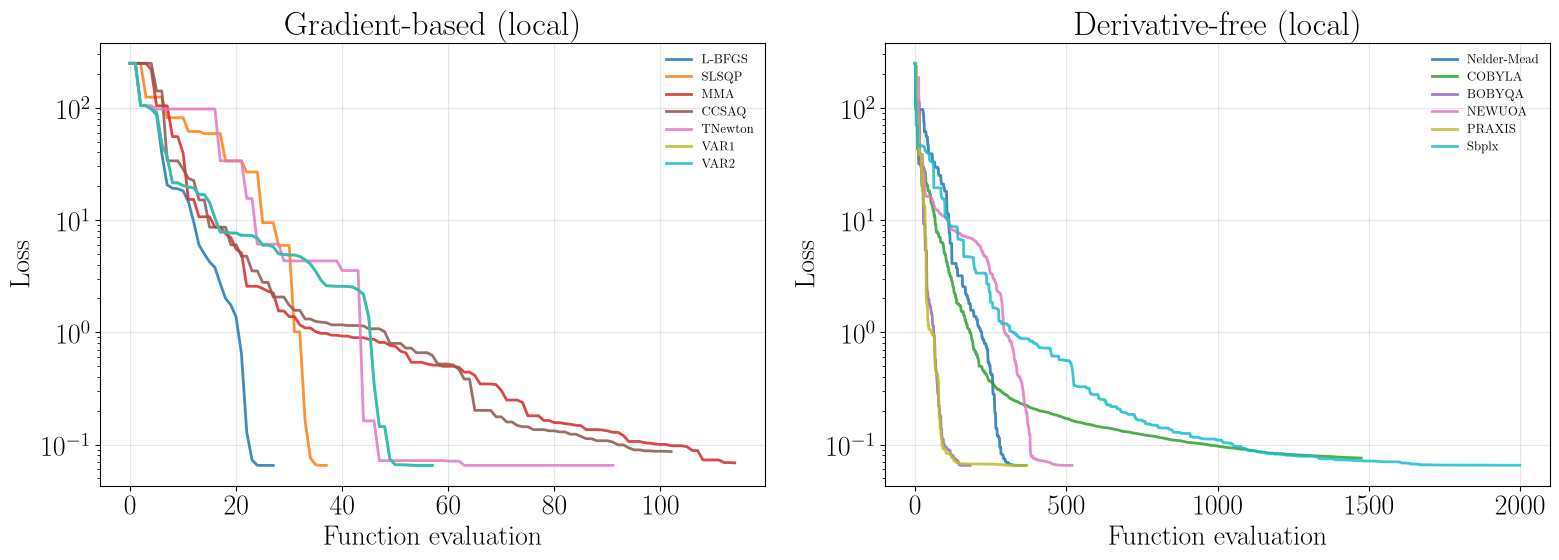

In [45]:
# ── Loss convergence: all local algorithms ────────────────────────────
window = 1000000

def rolling_min(losses, w=window):
    """Running best-so-far (rolling minimum)."""
    arr = np.array(losses)
    return np.array([np.min(arr[max(0, i - w + 1):i + 1]) for i in range(len(arr))])

fig_local, (ax_grad, ax_free) = plt.subplots(1, 2, figsize=(16, 6))

# ── Left panel: gradient-based algorithms ─────────────────────────────
grad_colors = plt.cm.tab10(np.linspace(0, 1, len(GRADIENT_BASED)))
for i, name in enumerate(n for n in LOCAL_ALGORITHMS if n in GRADIENT_BASED):
    res = local_algo_results[name]
    losses = res["history"]["loss"]
    y = rolling_min(losses)
    x = np.arange(len(y)) 
    ax_grad.semilogy(x, y, linewidth=2, label=name, color=grad_colors[i], alpha=0.85)

ax_grad.set_xlabel("Function evaluation")
ax_grad.set_ylabel("Loss")
ax_grad.set_title("Gradient-based (local)")
ax_grad.legend(frameon=False, fontsize=9)
ax_grad.grid(True, alpha=0.3)

# ── Right panel: derivative-free algorithms ───────────────────────────
free_names = [n for n in LOCAL_ALGORITHMS if n not in GRADIENT_BASED]
free_colors = plt.cm.tab10(np.linspace(0, 1, len(free_names)))
for i, name in enumerate(free_names):
    res = local_algo_results[name]
    losses = res["history"]["loss"]
    y = rolling_min(losses)
    x = np.arange(len(y))  # 1 function eval per step
    ax_free.semilogy(x, y, linewidth=2, label=name, color=free_colors[i], alpha=0.85)

ax_free.set_xlabel("Function evaluation")
ax_free.set_ylabel("Loss")
ax_free.set_title("Derivative-free (local)")
ax_free.legend(frameon=False, fontsize=9)
ax_free.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

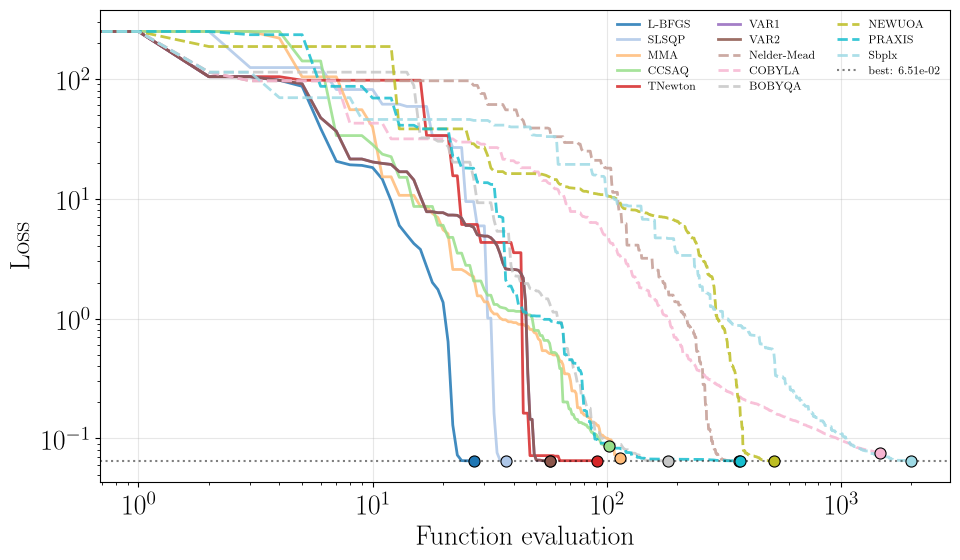

In [46]:
# ── Combined plot: all local algorithms on one axis ───────────────────
fig_local_all, ax_all = plt.subplots(figsize=(10, 6))

n_params_local = 1
all_local_names = list(LOCAL_ALGORITHMS.keys())
cmap = plt.cm.tab20(np.linspace(0, 1, len(all_local_names)))

for i, name in enumerate(all_local_names):
    res = local_algo_results[name]
    losses = res["history"]["loss"]
    y = rolling_min(losses)
    mult = n_params_local if name in GRADIENT_BASED else 1
    x = np.arange(len(y)) * mult
    ls = "-" if name in GRADIENT_BASED else "--"
    ax_all.semilogy(x, y, linestyle=ls, linewidth=2, label=name,
                    color=cmap[i], alpha=0.85)
    # Mark the final evaluation with a prominent dot
    ax_all.plot(x[-1], y[-1], marker='o', markersize=8, color=cmap[i],
                markeredgecolor='black', markeredgewidth=0.8, zorder=5)

best_loss = min(min(r["history"]["loss"]) for r in local_algo_results.values())
ax_all.axhline(best_loss, color="black", ls=":", lw=1.5, alpha=0.5,
               label=f"best: {best_loss:.2e}")

ax_all.set_xlabel("Function evaluation")
ax_all.set_ylabel("Loss")
ax_all.set_xscale("log")
ax_all.legend(frameon=False, ncol=3, loc="upper right", fontsize=8)
ax_all.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
# ── Save figures ──────────────────────────────────────────────────────
fig_local.savefig("./figures/local_algorithms_split.pdf", bbox_inches="tight")
print("Saved: local_algorithms_split.pdf")

fig_local_all.savefig("./figures/local_algorithms_combined.pdf", bbox_inches="tight")
print("Saved: local_algorithms_combined.pdf")

Saved: local_algorithms_split.pdf
Saved: local_algorithms_combined.pdf


# 10. Loss Landscape: Gradient Survey

In [48]:
# True parameters (same as Section 1)
s5_true_elements = {"Na": 0.5, "Mn": 0.25, "Mg": 0.20, "Ca": 0.05}
s5_true_T        = 8300.0
s5_true_ne       = 2.3e23
s5_true_L        = 3e-4
s5_element_names = list(s5_true_elements.keys())

# Number of LHS points
N_SURVEY = 100 # 200000 in paper, here: 100 for testing

# Read parameter bounds from a temporary optimizer (same approach as Section 2)
_s5_model = libskit.LTEModel(
    {el: 1.0 / len(s5_element_names) for el in s5_element_names},
    10000.0, 1e23, 1e-4,
)
_s5_exp = libskit.Experiment(
    libskit.LossType.L2Loss, _s5_model, instrument,
    experimental_spectrum, libskit.NormalizationType.AnalyticNorm,
)
_s5_opt = libskit.Optimizer(
    _s5_exp, parametrization=libskit.Parametrization.LOG_SOFTMAX_ALR
)
_s5_param_order = ['temperature', 'electron_density', 'length'] + s5_element_names
_s5_name_to_idx = {n: i for i, n in enumerate(_s5_opt.param_names)}
s5_bounds = {
    'lower': np.array([_s5_opt._lower[_s5_name_to_idx[n]] for n in _s5_param_order]),
    'upper': np.array([_s5_opt._upper[_s5_name_to_idx[n]] for n in _s5_param_order]),
}

# Generate LHS samples (reuse helper from Section 2)
s5_initial_guesses = generate_initial_guesses(N_SURVEY, s5_bounds, s5_element_names)

print(f"LHS gradient survey: N = {N_SURVEY} points")
print(f"T   range: [{s5_bounds['lower'][0]:.0f},  {s5_bounds['upper'][0]:.0f}] K")
print(f"ne  range: [{s5_bounds['lower'][1]:.2e}, {s5_bounds['upper'][1]:.2e}] m⁻³")
print(f"L   range: [{s5_bounds['lower'][2]:.2e}, {s5_bounds['upper'][2]:.2e}] m")

LHS gradient survey: N = 100 points
T   range: [5000,  50000] K
ne  range: [1.00e+22, 1.00e+24] m⁻³
L   range: [1.00e-05, 1.00e-02] m


In [49]:
# ── Worker: loss + internal-coordinate gradient at one physical point ──
def _survey_worker(args):
    """Return (idx, loss, internal-grad-norm) at a physical parameter point."""
    idx, guess = args

    model = libskit.LTEModel(
        guess['elements'],
        guess['temperature'],
        guess['electron_density'],
        guess['length'],
    )
    exp = libskit.Experiment(
        libskit.LossType.L2Loss, model, instrument,
        experimental_spectrum, libskit.NormalizationType.AnalyticNorm,
    )
    opt = libskit.Optimizer(exp, parametrization=libskit.Parametrization.LOG_SOFTMAX_ALR)

    f           = float(libskit.loss(exp))
    g_phys_dict = libskit.get_gradients(exp)  # Dict[str, float]

    # Physical parameter vector in param_names order (needed for log chain rule)
    phys_dict = {
        'temperature':      guess['temperature'],
        'electron_density': guess['electron_density'],
        'length':           guess['length'],
        **guess['elements'],
    }
    x_phys = np.array([phys_dict[n] for n in opt.param_names])

    # Internal-coordinate gradient (dimensionless)
    g_int = opt._param_strategy.chain_rule(g_phys_dict, x_phys)
    return idx, f, float(np.linalg.norm(g_int))


# ── Parallel evaluation ───────────────────────────────────────────────
s5_cache = Path('./results/s5_survey.pkl')
os.makedirs('./results', exist_ok=True)
force_rerun_s5 = False

if s5_cache.exists() and not force_rerun_s5:
    with open(s5_cache, 'rb') as fh:
        s5_data = pickle.load(fh)
    print(f"Loaded from cache: {len(s5_data['losses'])} points")
else:
    n_proc = min(mp.cpu_count(), N_SURVEY)
    print(f"Evaluating {N_SURVEY} points on {n_proc} processes …")
    t0 = time.time()
    with mp.Pool(processes=n_proc) as pool:
        out = pool.map(_survey_worker, list(enumerate(s5_initial_guesses)))
    out.sort(key=lambda r: r[0])
    s5_data = {
        'guesses':    s5_initial_guesses,
        'losses':     np.array([r[1] for r in out]),
        'grad_norms': np.array([r[2] for r in out]),
    }
    with open(s5_cache, 'wb') as fh:
        pickle.dump(s5_data, fh)
    print(f"Done in {time.time() - t0:.1f} s  →  cached to {s5_cache}")

print(f"Loss range:      {s5_data['losses'].min():.3e} … {s5_data['losses'].max():.3e}")
print(f"Grad-norm range: {s5_data['grad_norms'].min():.3e} … {s5_data['grad_norms'].max():.3e}")

Loaded from cache: 100 points
Loss range:      1.733e+02 … 4.009e+02
Grad-norm range: 5.396e+00 … 4.444e+02


In [50]:
# ── Loss and gradient at the true optimum ────────────────────────────
_s5_true_model = libskit.LTEModel(
    s5_true_elements, s5_true_T, s5_true_ne, s5_true_L
)
_s5_true_exp = libskit.Experiment(
    libskit.LossType.L2Loss, _s5_true_model, instrument,
    experimental_spectrum, libskit.NormalizationType.AnalyticNorm,
)
_s5_true_opt = libskit.Optimizer(
    _s5_true_exp, parametrization=libskit.Parametrization.LOG_SOFTMAX_ALR
)

s5_f_star        = float(libskit.loss(_s5_true_exp))
_g_phys_dict_opt = libskit.get_gradients(_s5_true_exp)  # Dict[str, float]
_phys_dict_opt   = {
    'temperature':      s5_true_T,
    'electron_density': s5_true_ne,
    'length':           s5_true_L,
    **s5_true_elements,
}
_x_phys_opt      = np.array([_phys_dict_opt[n] for n in _s5_true_opt.param_names])
_g_int_opt       = _s5_true_opt._param_strategy.chain_rule(_g_phys_dict_opt, _x_phys_opt)
s5_grad_norm_opt = float(np.linalg.norm(_g_int_opt))

print(f"f(θ_true)          = {s5_f_star:.4e}")
print(f"||∇f||  at θ_true  = {s5_grad_norm_opt:.4e}  (internal coords)")

f(θ_true)          = 6.5132e-02
||∇f||  at θ_true  = 4.6274e-02  (internal coords)


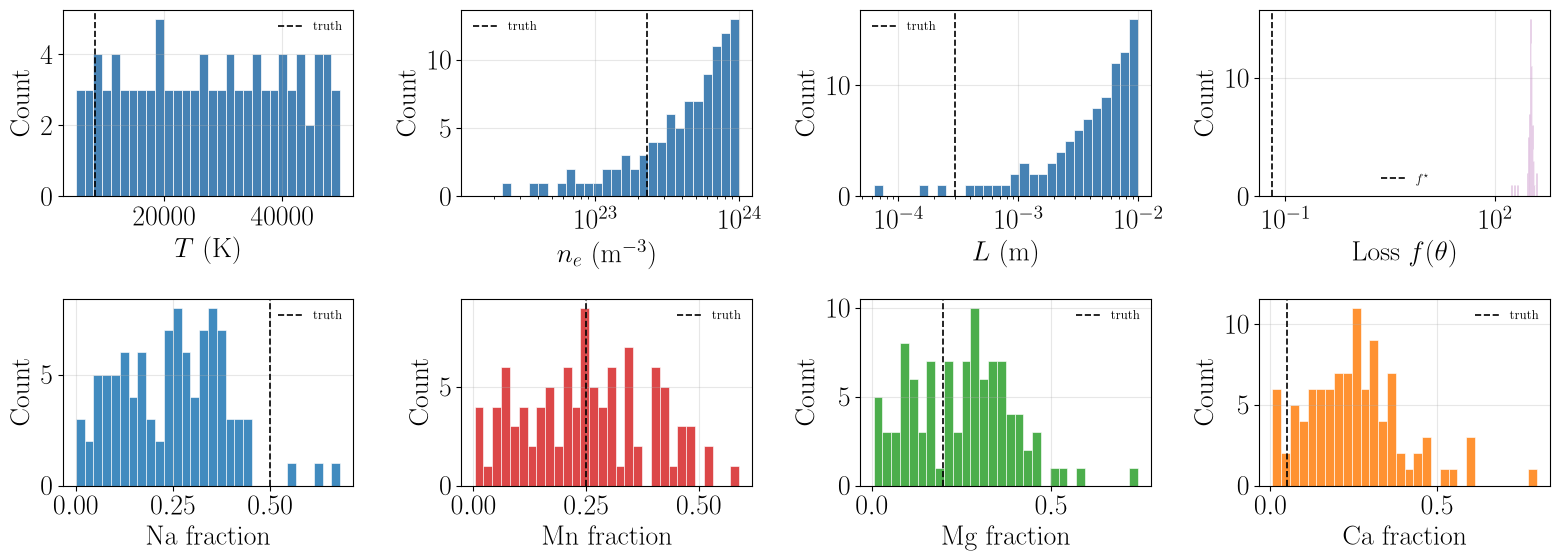

In [51]:
# ── Parameter distribution plots ──────────────────────────────────────
T_arr_s5   = np.array([g['temperature']      for g in s5_data['guesses']])
ne_arr_s5  = np.array([g['electron_density'] for g in s5_data['guesses']])
L_arr_s5   = np.array([g['length']           for g in s5_data['guesses']])
el_arr_s5  = {el: np.array([g['elements'][el] for g in s5_data['guesses']])
              for el in s5_element_names}

fig_s5dist, axes_dist = plt.subplots(2, 4, figsize=(16, 6))

# ── Top row: T, ne, L (physical params) + loss distribution ──────────
phys_params = [
    ('$T$ (K)',          T_arr_s5,  s5_true_T,  False),
    ('$n_e$ (m$^{-3}$)', ne_arr_s5, s5_true_ne, True),
    ('$L$ (m)',          L_arr_s5,  s5_true_L,  True),
]
for ax, (label, arr, truth, use_log) in zip(axes_dist[0, :3], phys_params):
    if use_log:
        bins = np.logspace(np.log10(arr.min()), np.log10(arr.max()), 30)
        ax.hist(arr, bins=bins, color='steelblue', edgecolor='white', linewidth=0.5)
        ax.set_xscale('log')
    else:
        ax.hist(arr, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.axvline(truth, color='k', ls='--', lw=1.2, label='truth')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(frameon=False, fontsize=9)
    ax.grid(True, alpha=0.3)

# Loss distribution in [0, 3]
ax_ldist = axes_dist[0, 3]
ax_ldist.hist(s5_data['losses'], bins=40, color='purple',
              edgecolor='white', linewidth=0.5, alpha=0.85)
ax_ldist.axvline(s5_f_star, color='k', ls='--', lw=1.2, label='$f^\\star$')
ax_ldist.set_xlabel('Loss $f(\\theta)$')
ax_ldist.set_ylabel('Count')
ax_ldist.set_xscale('log')
ax_ldist.legend(frameon=False, fontsize=9)
ax_ldist.grid(True, alpha=0.3)

# ── Bottom row: element ratios ─────────────────────────────────────────
elem_colors_s5 = {'Na': 'C0', 'Mn': 'C3', 'Mg': 'C2', 'Ca': 'C1'}
for i, el in enumerate(s5_element_names):
    ax = axes_dist[1, i]
    ax.hist(el_arr_s5[el], bins=30, color=elem_colors_s5[el],
            edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.axvline(s5_true_elements[el], color='k', ls='--', lw=1.2, label='truth')
    ax.set_xlabel(f'{el} fraction')
    ax.set_ylabel('Count')
    ax.legend(frameon=False, fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

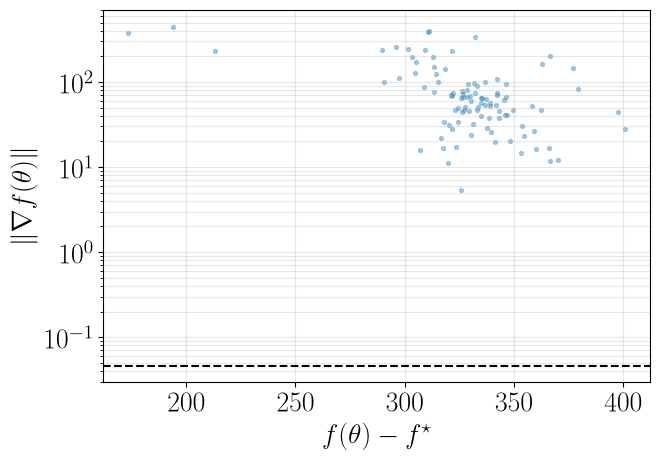

Saved: s5_parameter_distributions.pdf, s5_gradient_survey.pdf


In [52]:
# ── Gradient norm vs excess loss ──────────────────────────────────────
losses_s5     = s5_data['losses']
grad_norms_s5 = s5_data['grad_norms']
delta_f_s5    = losses_s5 - s5_f_star

fig_s5scatter, ax_s5 = plt.subplots(figsize=(7, 5))

ax_s5.scatter(delta_f_s5, grad_norms_s5,
              s=8, alpha=0.35, color='C0', rasterized=True,
              label=f'LHS samples ($N={N_SURVEY}$)')

# Horizontal line: gradient norm at the true optimum
ax_s5.axhline(s5_grad_norm_opt, color='black', ls='--', lw=1.5,
              label=fr'$\|\nabla f\|$ at $\theta^\star$ = {s5_grad_norm_opt:.2e}')

#ax_s5.set_xscale('log')
ax_s5.set_yscale('log')
ax_s5.set_xlabel(r'$f(\theta) - f^\star$')
ax_s5.set_ylabel(r'$\|\nabla f(\theta)\|$')
#ax_s5.legend(frameon=False)
ax_s5.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

fig_s5dist.savefig('./figures/s5_parameter_distributions.pdf', bbox_inches='tight')
fig_s5scatter.savefig('./figures/s5_gradient_survey.pdf', bbox_inches='tight', dpi=200)
print("Saved: s5_parameter_distributions.pdf, s5_gradient_survey.pdf")

Distance to truth:  min=1.113  median=3.203  max=4.571


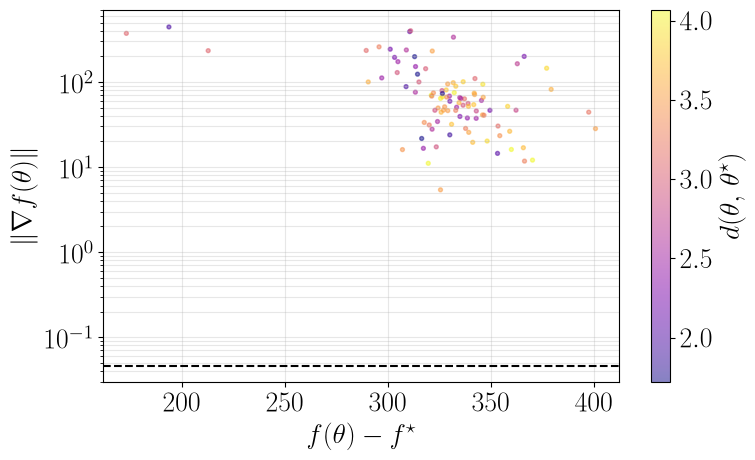

Saved: s5_gradient_survey_colored.pdf


In [53]:
# ── Gradient norm vs excess loss, colored by distance to truth ────────
# Distance metric (dimensionless):
#   log(T/T★), log(ne/ne★), log(L/L★)   — log-relative for scalar params
#   |c_i - c★_i|                          — absolute for element fractions
# All contributions are dimensionless and of comparable magnitude.

log_T_dist  = np.log(T_arr_s5  / s5_true_T)
log_ne_dist = np.log(ne_arr_s5 / s5_true_ne)
log_L_dist  = np.log(L_arr_s5  / s5_true_L)
el_dist_sq  = sum(
    (el_arr_s5[el] - s5_true_elements[el]) ** 2
    for el in s5_element_names
)
d_to_truth = np.sqrt(log_T_dist**2 + log_ne_dist**2 + log_L_dist**2 + el_dist_sq)
#d_to_truth = np.sqrt(log_T_dist**2)
#d_to_truth = np.sqrt(log_ne_dist**2)
#d_to_truth = np.sqrt(log_L_dist**2)
#d_to_truth = np.sqrt(el_dist_sq)

# calcium distance
#element = "Ca"
#d_to_truth = np.sqrt((el_arr_s5[element] - s5_true_elements[element]) ** 2)


print(f"Distance to truth:  min={d_to_truth.min():.3f}  median={np.median(d_to_truth):.3f}  "
      f"max={d_to_truth.max():.3f}")

fig_s5col, ax_s5col = plt.subplots(figsize=(8, 5))

sc = ax_s5col.scatter(
    delta_f_s5, grad_norms_s5,
    c=d_to_truth, cmap='plasma',
    s=8, alpha=0.5, rasterized=True,
    vmin=np.percentile(d_to_truth, 2),
    vmax=np.percentile(d_to_truth, 98),
)
cbar = fig_s5col.colorbar(sc, ax=ax_s5col)
cbar.set_label(r'$d(\theta,\,\theta^\star)$')

ax_s5col.axhline(s5_grad_norm_opt, color='black', ls='--', lw=1.5,
                 label=fr'$\|\nabla f\|$ at $\theta^\star$')
ax_s5col.set_yscale('log')
ax_s5col.set_xlabel(r'$f(\theta) - f^\star$')
ax_s5col.set_ylabel(r'$\|\nabla f(\theta)\|$')
#ax_s5col.legend(frameon=False, loc='upper left')
ax_s5col.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

fig_s5col.savefig('./figures/s5_gradient_survey_colored.pdf', bbox_inches='tight', dpi=200)
print("Saved: s5_gradient_survey_colored.pdf")

<>:19: SyntaxWarning: invalid escape sequence '\#'
<>:19: SyntaxWarning: invalid escape sequence '\#'
/tmp/ipykernel_17888/2964661721.py:19: SyntaxWarning: invalid escape sequence '\#'
  fig_s5dens.colorbar(hb1, ax=ax_dens, label='\# of points')


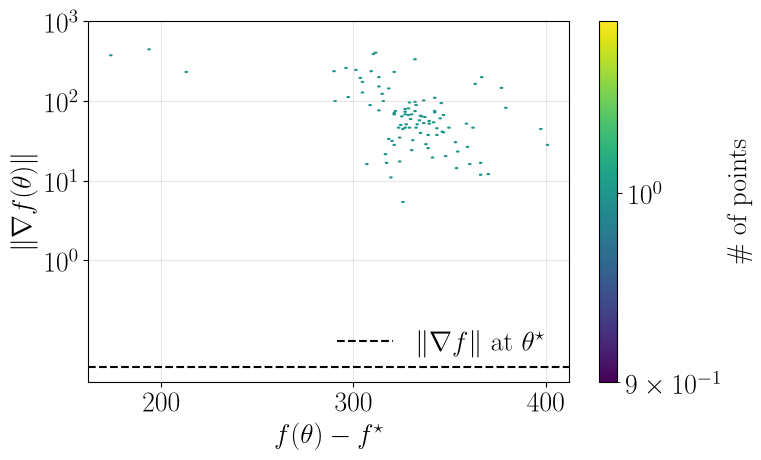

Saved: s5_gradient_survey_density.pdf


In [54]:
from matplotlib.colors import LogNorm

# Work in log10(grad_norm) so hexbin bins are uniform in the displayed space
log_grad = np.log10(grad_norms_s5)
log_grad_opt = np.log10(s5_grad_norm_opt)

# y-tick positions and labels (powers of 10 that span the range)
y_ticks_log = np.arange(np.floor(log_grad.min()), np.ceil(log_grad.max()) + 1)
y_tick_labels = [f'$10^{{{int(v)}}}$' for v in y_ticks_log]

fig_s5dens, ax_dens = plt.subplots(1, 1, figsize=(8, 5))

# ── (a) Point density ──────────────────────────────────────────────────
hb1 = ax_dens.hexbin(
    delta_f_s5, log_grad,
    gridsize=200, mincnt=1,
    cmap='viridis', norm=LogNorm(),
)
fig_s5dens.colorbar(hb1, ax=ax_dens, label='\# of points')
ax_dens.axhline(log_grad_opt, color='black', ls='--', lw=1.5,
                label=r'$\|\nabla f\|$ at $\theta^\star$')
ax_dens.set_xlabel(r'$f(\theta) - f^\star$')
ax_dens.set_ylabel(r'$\|\nabla f(\theta)\|$')
ax_dens.set_yticks(y_ticks_log)
ax_dens.set_yticklabels(y_tick_labels)
ax_dens.legend(frameon=False, loc='lower right')
ax_dens.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig_s5dens.savefig('./figures/s5_gradient_survey_density.pdf', bbox_inches='tight')
print("Saved: s5_gradient_survey_density.pdf")

Trajectory: 39 iterates, Δf: 2.487e+02 → -4.257e-06, ||∇f||: 4.196e+02 → 5.327e-04


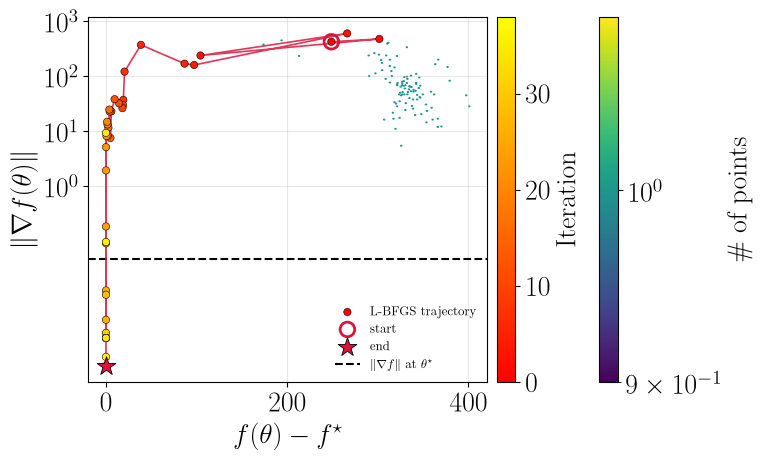

Saved: s5_gradient_survey_trajectory.pdf


In [55]:
# ── Overlay: single L-BFGS trajectory from the standard agnostic start ──
# The convergence_results.pkl stores loss + parameter values per iteration,
# but not gradient norms. To place trajectory points on the (Δf, ||∇f||)
# axes we recompute the gradient at each visited iterate. We do this for
# one representative trajectory launched from the same agnostic starting
# point used in Sections 1, 3, 4, 6.

# Standard agnostic starting point
_traj_start = {
    'elements':         {"Na": 0.25, "Mn": 0.25, "Mg": 0.25, "Ca": 0.25},
    'temperature':      10000.0,
    'electron_density': 1e23,
    'length':           1e-4,
}

_traj_model = libskit.LTEModel(
    dict(_traj_start['elements']),
    _traj_start['temperature'],
    _traj_start['electron_density'],
    _traj_start['length'],
)
_traj_exp = libskit.Experiment(
    libskit.LossType.L2Loss, _traj_model, instrument,
    experimental_spectrum, libskit.NormalizationType.AnalyticNorm,
)
_traj_opt = libskit.Optimizer(
    _traj_exp, parametrization=libskit.Parametrization.LOG_SOFTMAX_ALR
)
_traj_res = _traj_opt.optimize(
    algorithm=nlopt.LD_LBFGS, max_eval=500, verbose=False, xtol_rel=1e-6
)

# Recompute gradient norm (internal coords) at each iterate
_h = _traj_res['history']
_n_iters = len(_h['loss'])
traj_losses = np.asarray(_h['loss'])
traj_grad_norms = np.empty(_n_iters)

for i in range(_n_iters):
    phys = {
        'temperature':      _h['temperature'][i],
        'electron_density': _h['electron_density'][i],
        'length':           _h['length'][i],
        **{el: _h[el][i] for el in s5_element_names},
    }
    m = libskit.LTEModel(
        {el: phys[el] for el in s5_element_names},
        phys['temperature'], phys['electron_density'], phys['length'],
    )
    e = libskit.Experiment(
        libskit.LossType.L2Loss, m, instrument,
        experimental_spectrum, libskit.NormalizationType.AnalyticNorm,
    )
    o = libskit.Optimizer(e, parametrization=libskit.Parametrization.LOG_SOFTMAX_ALR)
    g_phys_dict = libskit.get_gradients(e)
    x_phys = np.array([phys[n] for n in o.param_names])
    g_int = o._param_strategy.chain_rule(g_phys_dict, x_phys)
    traj_grad_norms[i] = float(np.linalg.norm(g_int))

traj_delta_f = traj_losses - s5_f_star
print(f"Trajectory: {_n_iters} iterates, "
      f"Δf: {traj_delta_f[0]:.3e} → {traj_delta_f[-1]:.3e}, "
      f"||∇f||: {traj_grad_norms[0]:.3e} → {traj_grad_norms[-1]:.3e}")

# ── Replot density with trajectory overlay ────────────────────────────
fig_s5traj, ax_traj = plt.subplots(figsize=(8, 5))

hb = ax_traj.hexbin(
    delta_f_s5, log_grad,
    gridsize=200, mincnt=1,
    cmap='viridis', norm=LogNorm(),
)
fig_s5traj.colorbar(hb, ax=ax_traj, label='\\# of points')

# Trajectory: line + markers colored by iteration index
_log_traj_grad = np.log10(traj_grad_norms)
ax_traj.plot(traj_delta_f, _log_traj_grad,
             color='crimson', lw=1.2, alpha=0.85, zorder=3)
sc_traj = ax_traj.scatter(
    traj_delta_f, _log_traj_grad,
    c=np.arange(_n_iters), cmap='autumn',
    s=28, edgecolor='black', linewidth=0.4,
    zorder=4, label='L-BFGS trajectory',
)
cbar_traj = fig_s5traj.colorbar(sc_traj, ax=ax_traj, pad=0.02)
cbar_traj.set_label('Iteration')

# Mark start and end
ax_traj.scatter([traj_delta_f[0]], [_log_traj_grad[0]],
                marker='o', s=110, facecolor='none',
                edgecolor='crimson', lw=2.0, zorder=5, label='start')
ax_traj.scatter([traj_delta_f[-1]], [_log_traj_grad[-1]],
                marker='*', s=200, color='crimson',
                edgecolor='black', lw=0.6, zorder=5, label='end')

ax_traj.axhline(log_grad_opt, color='black', ls='--', lw=1.5,
                label=r'$\|\nabla f\|$ at $\theta^\star$')
ax_traj.set_xlabel(r'$f(\theta) - f^\star$')
ax_traj.set_ylabel(r'$\|\nabla f(\theta)\|$')
ax_traj.set_yticks(y_ticks_log)
ax_traj.set_yticklabels(y_tick_labels)
ax_traj.legend(frameon=False, loc='lower right', fontsize=9)
ax_traj.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig_s5traj.savefig('./figures/s5_gradient_survey_trajectory.pdf', bbox_inches='tight')
print("Saved: s5_gradient_survey_trajectory.pdf")


In [56]:
# print 3 closest LHS samples to the true optimum
best_idxs = np.argsort(d_to_truth)[:3]
print("3 closest LHS samples to θ★:")
for i, idx in enumerate(best_idxs):
    g = s5_data['guesses'][idx]

    print(f"Closest LHS sample to θ★  (index {idx})")
    print(f"  d(θ, θ★)        = {d_to_truth[idx]:.4f}")
    print(f"  f(θ) - f★       = {delta_f_s5[idx]:.4e}")
    print(f"  ||∇f||          = {grad_norms_s5[idx]:.4e}")
    print()
    print(f"  Parameter       sampled          true")
    print(f"  T (K)         {g['temperature']:>10.1f}     {s5_true_T:>10.1f}")
    print(f"  ne (m⁻³)   {g['electron_density']:>13.3e}  {s5_true_ne:>13.3e}")
    print(f"  L (m)        {g['length']:>12.3e}  {s5_true_L:>12.3e}")
    for el in s5_element_names:
        print(f"  {el}             {g['elements'][el]:>10.4f}     {s5_true_elements[el]:>10.4f}")
    print()

3 closest LHS samples to θ★:
Closest LHS sample to θ★  (index 87)
  d(θ, θ★)        = 1.1129
  f(θ) - f★       = 3.1453e+02
  ||∇f||          = 1.2361e+02

  Parameter       sampled          true
  T (K)            14702.0         8300.0
  ne (m⁻³)       1.035e+23      2.300e+23
  L (m)           2.444e-04     3.000e-04
  Na                 0.1461         0.5000
  Mn                 0.2379         0.2500
  Mg                 0.2417         0.2000
  Ca                 0.3744         0.0500

Closest LHS sample to θ★  (index 19)
  d(θ, θ★)        = 1.6486
  f(θ) - f★       = 3.1311e+02
  ||∇f||          = 1.9871e+02

  Parameter       sampled          true
  T (K)            14293.9         8300.0
  ne (m⁻³)       8.951e+23      2.300e+23
  L (m)           4.073e-04     3.000e-04
  Na                 0.0985         0.5000
  Mn                 0.2588         0.2500
  Mg                 0.0473         0.2000
  Ca                 0.5954         0.0500

Closest LHS sample to θ★  (index 34)
  